# EEE591/481 Computer Controlled Systems: Lab 3

Generative AI Statement: ChatGPT and Grok were used in the preparation of this Lab Report Addendum.

## Import Libraries

In [1]:
import sympy as sp
from sympy import Matrix, pi, sqrt, acos
import control as ct
from IPython.display import display

## Define Symbols

In [2]:
# System variables
y, h, D, u = sp.symbols('y h D u', real=True)
Fin, g, ri, ro = sp.symbols('F_{in} g r_i r_o', positive=True, real=True)

# Equilibrium symbols
he, De, ue = sp.symbols('he De ue', real=True)

In [3]:
# State variables
xdot_vect = \
    Matrix(
        [
            sp.Symbol(r'\dot{x_1}'),
            sp.Symbol(r'\dot{x_2}')
        ]
    )
xdot_vect

Matrix([
[\dot{x_1}],
[\dot{x_2}]])

In [4]:
x_vect = \
    Matrix(
        [
            sp.Symbol(r'x_1'),
            sp.Symbol(r'x_2')
        ]
    )
x_vect

Matrix([
[x_1],
[x_2]])

## Display State Variables

In [5]:
display(sp.Eq(sp.Symbol('x1'), h))
display(sp.Eq(sp.Symbol('x2'), D))
display(sp.Eq(sp.Symbol('u'), u))

Eq(x1, h)

Eq(x2, D)

Eq(u, u)

## Define $A_i$ and $A_o$

In [6]:
# Ai = pi*ri^2
# Ao = ro^2 * [ pi - 2(acos(D) - D*sqrt(1-D^2)) ]

Ai = pi * ri**2

Ao = ro**2 * (pi - 2*(sp.acos(D) - D*sp.sqrt(1 - D**2)))

display(sp.Eq(sp.Symbol('A_i'), Ai))
display(sp.Eq(sp.Symbol('A_o'), Ao))

Eq(A_i, pi*r_i**2)

Eq(A_o, r_o**2*(2*D*sqrt(1 - D**2) - 2*acos(D) + pi))

## Define Non-Linear State Equations

In [7]:
# hdot = Fin/Ai - (Ao/Ai)*sqrt(2*g*h)
# Ddot = -u
# y = h

f1 = Fin/Ai - (Ao/Ai)*sp.sqrt(2*g*h)
f2 = -u
y = h

display(sp.Eq(sp.Symbol(r'f_1(h,D,u)'), f1))
display(sp.Eq(sp.Symbol(r'f_2(h,D,u)'), f2))
display(sp.Eq(sp.Symbol('y'), y))

Eq(f_1(h,D,u), F_{in}/(pi*r_i**2) - sqrt(2)*sqrt(g)*sqrt(h)*r_o**2*(2*D*sqrt(1 - D**2) - 2*acos(D) + pi)/(pi*r_i**2))

Eq(f_2(h,D,u), -u)

Eq(y, h)

## Linearization

### Compute Jacobian Matrices Symbolically

In [8]:
# A = df/dx, B = df/du, C = dg/dx, D = dg/du

x = Matrix([h, D])
f = Matrix([f1, f2])

A_sym = f.jacobian(x)
B_sym = f.jacobian(Matrix([u]))
C_sym = Matrix([y]).jacobian(x)
D_sym = Matrix([y]).jacobian(Matrix([u]))

In [9]:
display(sp.Symbol('A'))
display(A_sym)

A

Matrix([
[-sqrt(2)*sqrt(g)*r_o**2*(2*D*sqrt(1 - D**2) - 2*acos(D) + pi)/(2*pi*sqrt(h)*r_i**2), -sqrt(2)*sqrt(g)*sqrt(h)*r_o**2*(-2*D**2/sqrt(1 - D**2) + 2*sqrt(1 - D**2) + 2/sqrt(1 - D**2))/(pi*r_i**2)],
[                                                                                  0,                                                                                                          0]])

In [10]:
display(sp.Symbol('B'))
display(B_sym)

B

Matrix([
[ 0],
[-1]])

In [11]:
display(sp.Symbol('C'))
display(C_sym)

C

Matrix([[1, 0]])

In [12]:
display(sp.Symbol('D'))
display(D_sym)

D

Matrix([[0]])

#### Display Individual Derivatives used in Jacobian Calculations

In [13]:
df1_dh = sp.simplify(sp.diff(f1, h))
df1_dD = sp.simplify(sp.diff(f1, D))
df2_dh = sp.simplify(sp.diff(f2, h))
df2_dD = sp.simplify(sp.diff(f2, D))
df1_du = sp.simplify(sp.diff(f1, u))
df2_du = sp.simplify(sp.diff(f2, u))
dy_dh = sp.simplify(sp.diff(y, h))
dy_dD = sp.simplify(sp.diff(y, D))
dy_du = sp.simplify(sp.diff(y, u))

display(sp.Eq(sp.Symbol(r'\partial f_{1} / \partial h'), df1_dh))
display(sp.Eq(sp.Symbol(r'\partial f_{1} / \partial D'), df1_dD))
display(sp.Eq(sp.Symbol(r'\partial f_{2} / \partial h'), df2_dh))
display(sp.Eq(sp.Symbol(r'\partial f_{2} / \partial D'), df2_dD))
display(sp.Eq(sp.Symbol(r'\partial f_{1} / \partial u'), df1_du))
display(sp.Eq(sp.Symbol(r'\partial f_{2} / \partial u'), df2_du))
display(sp.Eq(sp.Symbol(r'\partial y / \partial h'), dy_dh))
display(sp.Eq(sp.Symbol(r'\partial y / \partial D'), dy_dD))
display(sp.Eq(sp.Symbol(r'\partial y / \partial u'), dy_du))

Eq(\partial f_{1} / \partial h, sqrt(2)*sqrt(g)*r_o**2*(-D*sqrt(1 - D**2) + acos(D) - pi/2)/(pi*sqrt(h)*r_i**2))

Eq(\partial f_{1} / \partial D, -4*sqrt(2)*sqrt(g)*sqrt(h)*r_o**2*sqrt(1 - D**2)/(pi*r_i**2))

Eq(\partial f_{2} / \partial h, 0)

Eq(\partial f_{2} / \partial D, 0)

Eq(\partial f_{1} / \partial u, 0)

Eq(\partial f_{2} / \partial u, -1)

Eq(\partial y / \partial h, 1)

Eq(\partial y / \partial D, 0)

Eq(\partial y / \partial u, 0)

### Subsitute Numerical Values

In [14]:
# Substitute the numerical values from the lab
# Lab values:
# Fin = 0.00339
# g = 9.80665
# ri = 0.15
# ro = 0.02
# he = 1
# De = 0.5
# ue = 0

vals = {
    Fin: 0.00339,
    g: 9.80665,
    ri: 0.15,
    ro: 0.02,
    he: 1.0,
    De: 0.5,
    ue: 0.0
}

### Evaluate $A_i$ and $A_o$ at Equilibrium

In [15]:
Ai_num = sp.N(Ai.subs(vals), n=6)
Ao_num = sp.N(Ao.subs({**vals, D: vals[De]}), n=6)

display(sp.Eq(sp.Symbol('A_i'), Ai_num))
display(sp.Eq(sp.Symbol(r'A_{o}(D_e)'), Ao_num))

Eq(A_i, 0.0706858)

Eq(A_{o}(D_e), 0.000765289)

### Verify Equilibrium Condition

In [16]:
f1_eq = sp.simplify(f1.subs({
    Fin: vals[Fin], g: vals[g], ri: vals[ri], ro: vals[ro],
    h: vals[he], D: vals[De]
}))
f2_eq = sp.simplify(f2.subs({u: vals[ue]}))

display(sp.Eq(sp.Symbol(r'f_1(h_e,D_e,u_e)'), sp.N(f1_eq, n=6)))
display(sp.Eq(sp.Symbol(r'f_2(h_e,D_e,u_e)'), sp.N(f2_eq, n=6)))

Eq(f_1(h_e,D_e,u_e), 1.09079e-5)

Eq(f_2(h_e,D_e,u_e), 0)

### Evaluate the Jacobians at the Equilibrium

In [17]:
A_num = sp.N(
    A_sym.subs(
        {
            Fin: vals[Fin], g: vals[g], ri: vals[ri], ro: vals[ro],
            h: vals[he], D: vals[De], u: vals[ue]
        }
    ), n=6
)

B_num = sp.N(
    B_sym.subs(
        {
            Fin: vals[Fin], g: vals[g], ri: vals[ri], ro: vals[ro],
            h: vals[he], D: vals[De], u: vals[ue]
        }
    ), n=6
)

C_num = sp.N(
    C_sym.subs(
        {
            h: vals[he], D: vals[De], u: vals[ue]
        }
    ), n=6
)

D_num = sp.N(
    D_sym.subs(
        {
            h: vals[he], D: vals[De], u: vals[ue]
        }
    ), n=6
)

### Evaluate $\frac{\partial f_1}{\partial h}$ Numerically

In [18]:
print("At equilibrium = ")
A_num[0, 0]

At equilibrium = 


-0.0239739

### Evaluate $\frac{\partial f_1}{\partial D}$ Numerically

In [19]:
print("At equilibrium = ")
A_num[0, 1]

At equilibrium = 


-0.0868148

### Display System Matrices

In [20]:
print('A evaluated at equilibrium')
display(sp.Symbol('A='))
display(A_num)

A evaluated at equilibrium


A=

Matrix([
[-0.0239739, -0.0868148],
[         0,          0]])

In [21]:
print('B evaluated at equilibrium')
display(sp.Symbol('B='))
display(B_num)

B evaluated at equilibrium


B=

Matrix([
[   0],
[-1.0]])

In [22]:
print('C evaluated at equilibrium')
display(sp.Symbol('C='))
display(C_num)

C evaluated at equilibrium


C=

Matrix([[1.0, 0]])

In [23]:
print('D evaluated at equilibrium')
display(sp.Symbol('D='))
display(D_num)

D evaluated at equilibrium


D=

Matrix([[0]])

### Show Partial Derivative Numerical Values

In [24]:
display(
    sp.Eq(
        sp.Symbol(
            r'(\partial f_{1}/\partial h)|_e'),
            sp.N(
                df1_dh.subs(
                    {
                        Fin: vals[Fin], g: vals[g], ri: vals[ri], ro: vals[ro],
                      h: vals[he], D: vals[De]
                    }
                ), n=6
            )
    )
)

Eq((\partial f_{1}/\partial h)|_e, -0.0239739)

In [25]:
display(
    sp.Eq(
        sp.Symbol(
            r'(\partial f_{1}/\partial D)|_e'),
            sp.N(
                df1_dD.subs(
                    {
                        Fin: vals[Fin], g: vals[g], ri: vals[ri], ro: vals[ro],
                        h: vals[he], D: vals[De]
                    }
                ), n=6
            )
    )
) 

Eq((\partial f_{1}/\partial D)|_e, -0.0868148)

In [26]:
display(
    sp.Eq(
        sp.Symbol(
            r'(\partial f_{2}/\partial h)|_e'),
            sp.N(
                df2_dh.subs(
                    {
                        h: vals[he], D: vals[De], u: vals[ue]
                    }
                ), n=6
            )
    )
)

Eq((\partial f_{2}/\partial h)|_e, 0)

In [27]:
display(
    sp.Eq(
        sp.Symbol(
            r'(\partial f_{2}/\partial D)|_e'),
            sp.N(
                df2_dD.subs(
                    {
                        h: vals[he], D: vals[De], u: vals[ue]
                    }
                ), n=6
            )
    )
)

Eq((\partial f_{2}/\partial D)|_e, 0)

In [28]:
display(
    sp.Eq(
        sp.Symbol(
            r'(\partial f_{1}/\partial u)|_e'),
            sp.N(
                df1_du.subs(
                    {
                        h: vals[he], D: vals[De], u: vals[ue]
                    }
                ), n=6
            )
    )
)

Eq((\partial f_{1}/\partial u)|_e, 0)

In [29]:
display(
    sp.Eq(
        sp.Symbol(
            r'(\partial f_{2}/\partial u)|_e'),
            sp.N(
                df2_du.subs(
                    {
                        h: vals[he], D: vals[De], u: vals[ue]
                    }
                ), n=6
        )
    )
)

Eq((\partial f_{2}/\partial u)|_e, -1.0)

In [30]:
display(
    sp.Eq(
        sp.Symbol(
            r'(\partial y/\partial h)|_e'),
            sp.N(
              dy_dh.subs(
                  {
                      h: vals[he], D: vals[De], u: vals[ue]
                  }
              ), n=6
        )
    )
)

Eq((\partial y/\partial h)|_e, 1.0)

In [31]:
display(
    sp.Eq(
        sp.Symbol(
            r'(\partial y/\partial D)|_e'),
            sp.N(
                dy_dD.subs(
                    {
                        h: vals[he], D: vals[De], u: vals[ue]
                    }
                ), n=6
        )
    )
)

Eq((\partial y/\partial D)|_e, 0)

In [32]:
display(
    sp.Eq(
        sp.Symbol(
            r'(\partial y/\partial u)|_e'),
            sp.N(
                dy_du.subs(
                    {
                        h: vals[he], D: vals[De], u: vals[ue]
                    }
                ), n=6
            )
    )
)

Eq((\partial y/\partial u)|_e, 0)

### Show Numerical Results for ABCD Matrices

In [33]:
print("A =")
A_num

A =


Matrix([
[-0.0239739, -0.0868148],
[         0,          0]])

In [34]:
print("\nB =")
B_num


B =


Matrix([
[   0],
[-1.0]])

In [35]:
print("\nC =")
C_num


C =


Matrix([[1.0, 0]])

In [36]:
print("\nD =")
D_num


D =


Matrix([[0]])

### Display Linearzied Model State Space Equations

In [37]:
Ax = sp.MatMul(A_num, x_vect, evaluate=False)
Bu = sp.MatMul(B_num, u, evaluate=False)

rhs = sp.MatAdd(Ax, Bu, evaluate=False)

state_eq_num = sp.Eq(xdot_vect, rhs)
display(state_eq_num)

Eq(Matrix([
[\dot{x_1}],
[\dot{x_2}]]), Matrix([
[   0],
[-1.0]])*u + Matrix([
[-0.0239739, -0.0868148],
[         0,          0]])*Matrix([
[x_1],
[x_2]]))

In [38]:
Cx = sp.MatMul(C_num, x_vect, evaluate=False)
Du = sp.MatMul(D_num, u, evaluate=False)

rhs_y = sp.MatAdd(Cx, Du, evaluate=False)

output_eq = sp.Eq(y, rhs_y, evaluate=False)
display(output_eq)

Eq(h, Matrix([[0]])*u + Matrix([[1.0, 0]])*Matrix([
[x_1],
[x_2]]))

### Plot Non-linear Function and Show Equilibrium Point

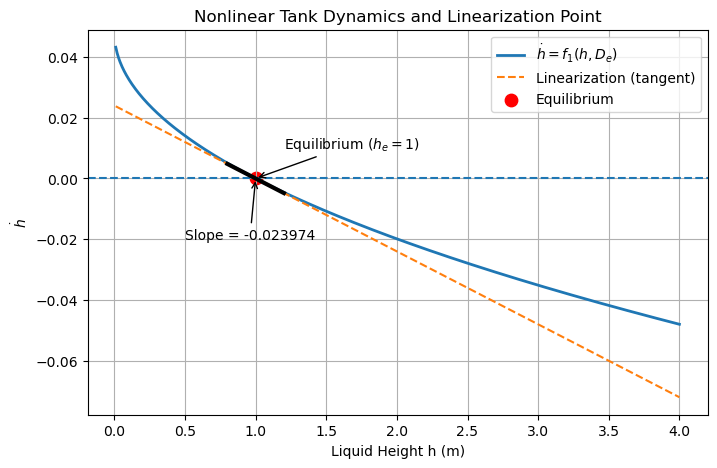

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Step 1: Define symbols
# ============================================================
h, D = sp.symbols('h D')

Fin = 0.00339
g = 9.80665
ri = 0.15
ro = 0.02

Ai = np.pi*ri**2

# Ao function
Ao = ro**2*(sp.pi - 2*(sp.acos(D) - D*sp.sqrt(1-D**2)))

# Nonlinear function
f1 = Fin/Ai - (Ao/Ai)*sp.sqrt(2*g*h)

# ============================================================
# Step 2: Substitute equilibrium D value
# ============================================================
f1_De = f1.subs(D,0.5)

# Convert to numeric function
f_numeric = sp.lambdify(h, f1_De, 'numpy')

# ============================================================
# Step 3: Generate data
# ============================================================
h_vals = np.linspace(0.01,4,800)
f_vals = f_numeric(h_vals)

# Equilibrium
he = 1
fe = f_numeric(he)

# Derivative for linearization slope
dfdh = sp.diff(f1_De,h)
dfdh_num = float(dfdh.subs(h,he))

# Tangent line
tangent = dfdh_num*(h_vals-he)

# ============================================================
# Step 4: Plot nonlinear function
# ============================================================
plt.figure(figsize=(8,5))

plt.plot(h_vals, f_vals, linewidth=2,
         label=r'$\dot h = f_1(h,D_e)$')

plt.plot(h_vals,tangent,
         linestyle='--',
         label='Linearization (tangent)')

plt.axhline(0, linestyle='--')

# Mark equilibrium
plt.scatter(he, fe, color='red', s=80,
            label='Equilibrium')

plt.annotate(r'Equilibrium $(h_e=1)$',
             xy=(he,fe),
             xytext=(1.2,0.01),
             arrowprops=dict(arrowstyle='->'))

# ============================================================
# Annotate slope at equilibrium
# ============================================================
# Draw a small segment to visualize slope
delta_h = 0.2
h_line = np.array([he - delta_h, he + delta_h])
tangent_line = dfdh_num * (h_line - he)

plt.plot(h_line, tangent_line, color='black', linewidth=3)

# Annotate slope value
plt.annotate(rf'Slope = {dfdh_num:.6f}',
             xy=(he, fe),
             xytext=(he - 0.5, fe - 0.02),
             arrowprops=dict(arrowstyle='->'))

plt.xlabel("Liquid Height h (m)")
plt.ylabel(r'$\dot h$')
plt.title("Nonlinear Tank Dynamics and Linearization Point")

plt.grid()
plt.legend()

plt.show()

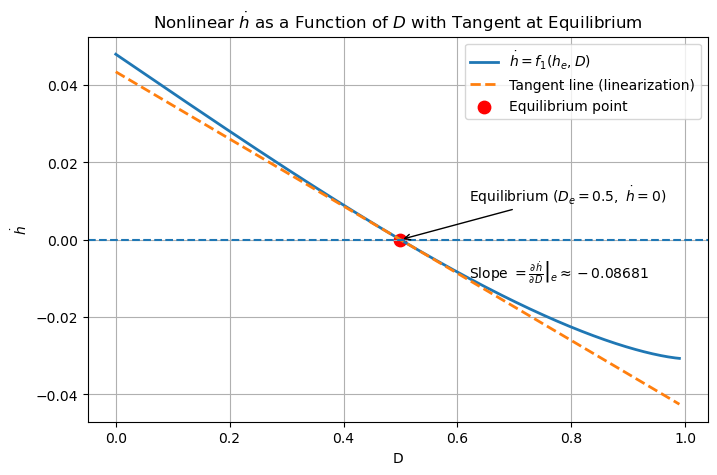

In [40]:
# ============================================================
# Step 1: Define symbols
# ============================================================
h, D = sp.symbols('h D', real=True)

Fin = 0.00339
g = 9.80665
ri = 0.15
ro = 0.02

Ai = np.pi * ri**2

# Outlet area Ao(D)
Ao = ro**2 * (sp.pi - 2*(sp.acos(D) - D*sp.sqrt(1 - D**2)))

# Nonlinear function h_dot = f1(h,D)
f1 = Fin/Ai - (Ao/Ai) * sp.sqrt(2*g*h)

# ============================================================
# Step 2: Fix h at the equilibrium value h_e = 1
# ============================================================
he = 1.0
De = 0.5

f1_he = sp.simplify(f1.subs(h, he))

# Convert to numeric function of D
f_numeric = sp.lambdify(D, f1_he, 'numpy')

# ============================================================
# Step 3: Compute tangent line at D_e = 0.5
# ============================================================
dfdD = sp.diff(f1_he, D)
dfdD_num = float(dfdD.subs(D, De))

# Equilibrium value
fe = float(f1_he.subs(D, De))

# Tangent line: f(D) ~ f(De) + f'(De)(D - De)
D_vals = np.linspace(0.0, 0.99, 400)
f_vals = f_numeric(D_vals)
tangent_vals = fe + dfdD_num * (D_vals - De)

# ============================================================
# Step 4: Plot nonlinear function and tangent line
# ============================================================
plt.figure(figsize=(8, 5))

plt.plot(D_vals, f_vals, linewidth=2, label=r'$\dot{h} = f_1(h_e,D)$')
plt.plot(D_vals, tangent_vals, '--', linewidth=2, label='Tangent line (linearization)')

plt.axhline(0, linestyle='--')

# Mark equilibrium point
plt.scatter(De, fe, s=80, color='red', label='Equilibrium point')

plt.annotate(r'Equilibrium $(D_e=0.5,\ \dot{h}=0)$',
             xy=(De, fe),
             xytext=(0.62, 0.01),
             arrowprops=dict(arrowstyle='->'))

# Optional slope annotation
plt.text(0.62, -0.01, rf'Slope $= \left.\frac{{\partial \dot{{h}}}}{{\partial D}}\right|_e \approx {dfdD_num:.5f}$')

plt.xlabel('D')
plt.ylabel(r'$\dot{h}$')
plt.title(r'Nonlinear $\dot{h}$ as a Function of $D$ with Tangent at Equilibrium')
plt.grid(True)
plt.legend()
plt.show()

## Convert into State Space Form

### Define the Laplace variable $s$

In [41]:
s = sp.symbols('s', complex=True)

### Form $sI - A$

In [42]:
I = sp.eye(A_num.shape[0])
I

Matrix([
[1, 0],
[0, 1]])

In [43]:
s*I

Matrix([
[s, 0],
[0, s]])

In [44]:
A_num

Matrix([
[-0.0239739, -0.0868148],
[         0,          0]])

In [45]:
sI_minus_A = s*I - A_num
display(sp.Symbol(r'sI - A ='))
display(sI_minus_A)

sI - A =

Matrix([
[s + 0.0239739, 0.0868148],
[            0,         s]])

### Compute $(sI - A)^{-1}$ 

In [46]:
sI_minus_A_inv = sp.simplify(sI_minus_A.inv())

display(sp.Symbol(r'(sI - A)^{-1} ='))
display(sI_minus_A_inv)

(sI - A)^{-1} =

Matrix([
[1.0/(1.0*s + 0.0239739), -0.0868148/(s*(1.0*s + 0.0239739))],
[                      0,                              1.0/s]])

### Multiply $(sI - A)^{-1}B$

In [47]:
middle_term = sp.simplify(sI_minus_A_inv * B_num)

display(sp.Symbol(r'(sI - A)^{-1} B ='))
display(middle_term)

(sI - A)^{-1} B =

Matrix([
[0.0868148/(s*(1.0*s + 0.0239739))],
[                           -1.0/s]])

### Compute $G(s) = C (sI - A)^{-1} B + D$

In [48]:
G = sp.simplify(C_num * middle_term + D_num)

display(sp.Symbol(r'G(s) = C(sI-A)^{-1}B + D'))
display(sp.Eq(sp.Symbol(r'G(s)'), G[0]))

G(s) = C(sI-A)^{-1}B + D

Eq(G(s), 0.0868148/(s*(1.0*s + 0.0239739)))

### Extract the scalar transfer function

In [49]:
G_scalar = sp.simplify(G[0])

display(sp.Symbol(r'G(s) = '))
display(G_scalar)

G(s) = 

0.0868148/(s*(1.0*s + 0.0239739))

### Write numerator and denominator explicitly

In [50]:
num, den = sp.fraction(sp.together(G_scalar))
num = sp.expand(num)
den = sp.expand(den)

In [51]:
display(sp.Symbol('Numerator ='))
display(num)

Numerator =

0.0868148

In [52]:
display(sp.Symbol('Denominator ='))
display(den)

Denominator =

1.0*s**2 + 0.0239739*s

### Factor the denominator

In [53]:
den_factored = sp.factor(den)

display(sp.Symbol('Factored\; denominator ='))
display(den_factored)

Factored\; denominator =

1.0*s*(1.0*s + 0.0239739)

### Final result

In [54]:
display(sp.Eq(sp.Symbol(r'G(s)'), G_scalar))

Eq(G(s), 0.0868148/(s*(1.0*s + 0.0239739)))

### Verification using adjugate/determinant formula

In [55]:
# G(s) = C * adj(sI-A)/det(sI-A) * B + D
det_term = sp.expand(sI_minus_A.det())
adj_term = sI_minus_A.adjugate()

In [56]:
display(sp.Symbol(r'\det(sI-A) = '))
display(det_term)

\det(sI-A) = 

s**2 + 0.0239739*s

In [57]:
display(sp.Symbol(r'\operatorname{adj}(sI-A) = '))
display(adj_term)

\operatorname{adj}(sI-A) = 

Matrix([
[s,    -0.0868148],
[0, s + 0.0239739]])

In [58]:
G_check = sp.simplify(C_num * adj_term * B_num / det_term + D_num)

display(sp.Symbol(r'G_{check}(s) ='))
display(G_check[0])

G_{check}(s) =

0.0868148/(s*(s + 0.0239739))

### Plot Bode and Step Response

A =
 [[-0.02397388 -0.08681473]
 [ 0.          0.        ]]

B =
 [[ 0.]
 [-1.]]

C =
 [[1. 0.]]

D =
 [[0.]]

Transfer Function:
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      0.08681
  ---------------
  s^2 + 0.02397 s


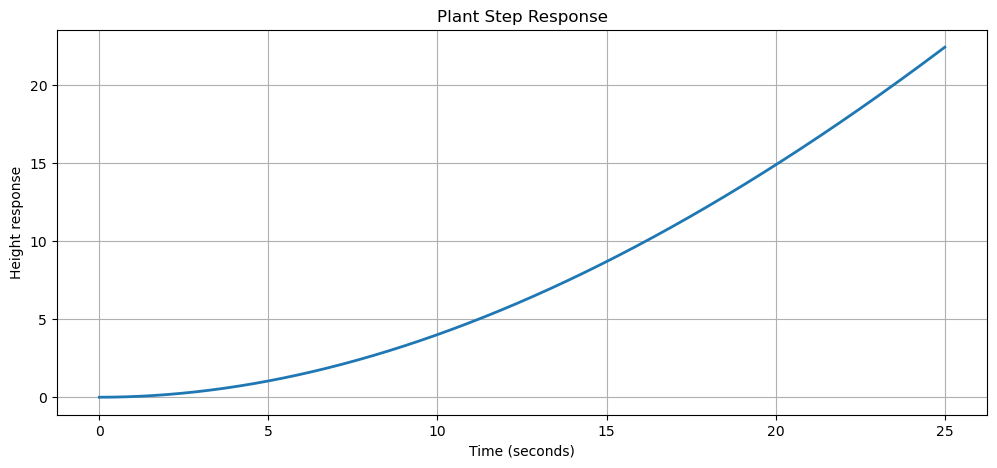

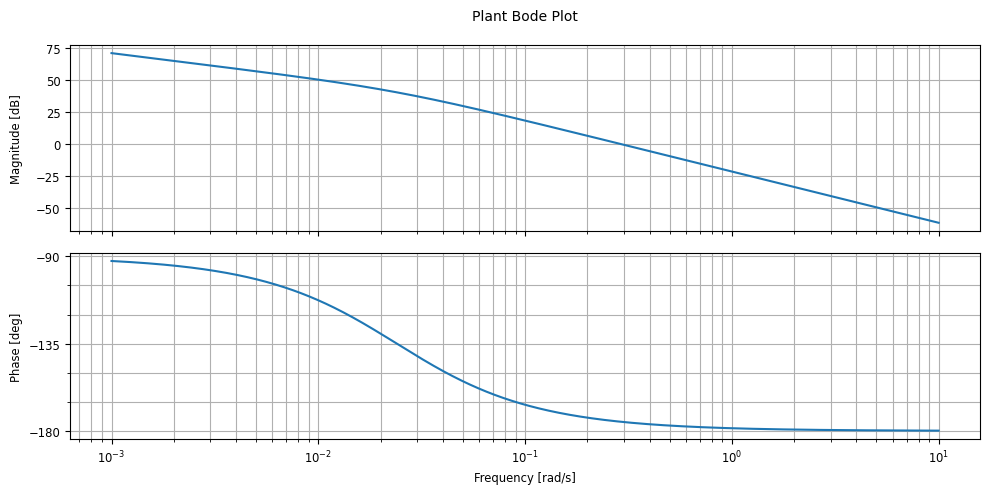

In [59]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

# ============================================================
# Lab parameters
# ============================================================
Fin = 0.00339
g = 9.80665
ri = 0.15
ro = 0.02

Ai = np.pi * ri**2

# ============================================================
# Outlet area function
# ============================================================
def Ao_of_D(D):
    return ro**2*(np.pi - 2*(np.arccos(D) - D*np.sqrt(1-D**2)))

# ============================================================
# Nonlinear state equations
# ============================================================
def tank_update(t,x,u,params=None):

    h = x[0]
    D = x[1]

    uval = u[0] if np.ndim(u)>0 else u

    hdot = Fin/Ai - (Ao_of_D(D)/Ai)*np.sqrt(2*g*h)
    Ddot = -uval

    return np.array([hdot,Ddot])

# ============================================================
# Output equation
# ============================================================
def tank_output(t,x,u,params=None):

    return np.array([x[0]])

# ============================================================
# Create nonlinear system
# ============================================================
tank_nl = ct.NonlinearIOSystem(
    tank_update,
    tank_output,
    states=2,
    inputs=1,
    outputs=1,
    name='tank'
)

# ============================================================
# Equilibrium point
# ============================================================
xeq = np.array([1.0,0.5])
ueq = np.array([0.0])

# ============================================================
# Linearize (MATLAB linmod equivalent)
# ============================================================
tank_lin = ct.linearize(tank_nl,xeq,ueq)

A = tank_lin.A
B = tank_lin.B
C = tank_lin.C
D = tank_lin.D

print("A =\n",A)
print("\nB =\n",B)
print("\nC =\n",C)
print("\nD =\n",D)

# ============================================================
# Transfer function
# ============================================================
G = ct.tf(tank_lin)

print("\nTransfer Function:")
print(G)

# ============================================================
# STEP RESPONSE
# ============================================================
plt.figure(figsize=(12,5))

t,y = ct.step_response(G, timepts_num=1000)

plt.plot(t,y,linewidth=2)

plt.title("Plant Step Response")
plt.xlabel("Time (seconds)")
plt.ylabel("Height response")

plt.grid()

plt.show()

# ============================================================
# BODE PLOT
# ============================================================
plt.figure(figsize=(10,5))

omega = np.logspace(-3,1,1000)   # from 0.001 to 100 rad/s

ct.bode_plot(G,omega=omega, dB=True,Hz=False,deg=True,grid=True, title='Plant Bode Plot')

plt.show()

## Verify with Python Control Systems Library

In [60]:
sys = ct.ss(A_num, B_num, C_num, D_num)
sys

StateSpace(
array([[-0.02397389, -0.08681476],
       [ 0.        ,  0.        ]]),
array([[ 0.],
       [-1.]]),
array([[1., 0.]]),
array([[0.]]),
states=2, outputs=1, inputs=1)

In [61]:
G = ct.tf(sys)
G

TransferFunction(
array([0.08681476]),
array([1.        , 0.02397389, 0.        ]),
outputs=1, inputs=1)

### Answer: The resulting CT transfer functions are the same when doing the calculations by hand and when using the 'tf' command.

## Calculations 3.1

Design a PID controller for the linearized plant that has a bandwidth of 10 rad/sec and a phase margin of 60◦. Use $\tau$ = 0.0009 for the pseudo pole. The structure for a PID controller in continuous time is:
$$
C(s) = \frac{K(s+a)^2}{s(\tau s+1)}
$$

In [62]:
from sympy import I, Matrix, Eq, pi, atan, sqrt, N

### Define symbols and known constants

In [63]:
w, a, K = sp.symbols('omega a K', positive=True, real=True)

In [64]:
tau = sp.Float('0.0009')
plant_num = sp.Float('0.08681')
p1 = sp.Float('0.02397')

### Target Specifications for Bandwidth and Phase Margin

In [65]:
BW = sp.Float('10.0')          # desired bandwidth [rad/s]
PM = sp.Float('60.0')          # desired phase margin [deg]

### Define Gain Crossover Frequency in $[rad/sec]$

In [66]:
# Use the standard PM~60° rule of thumb:
# bandwidth ~ 1.5 * gain crossover frequency
wgc = BW / sp.Float('1.5')
display(Eq(sp.Symbol(r'\omega_{gc}'), wgc))

Eq(\omega_{gc}, 6.66666666666667)

### Display Design Parameters

#### Display Design Bandwidth in $[rad/sec]$

In [67]:
display(Eq(sp.Symbol(r'\omega_{BW}'), BW))

Eq(\omega_{BW}, 10.0)

#### Display Design Phase Margin in $[degrees]$

In [68]:
display(Eq(sp.Symbol(r'PM'), PM))

Eq(PM, 60.0)

#### Display Gain Crossover Frequency in $[rad/sec]$

In [69]:
display(Eq(sp.Symbol(r'\omega_{gc}'), wgc))

Eq(\omega_{gc}, 6.66666666666667)

### Define Plant and Controller

In [70]:
# ============================================================
# P(s) = 0.08681 / [ s (s + 0.02397) ]
# C(s) = K (s+a)^2 / [ s (tau s + 1) ]
# ============================================================
s = sp.symbols('s')

P = plant_num / (s * (s + p1))
C = K * (s + a)**2 / (s * (tau*s + 1))
L = sp.simplify(P * C)

#### Display Plant Transfer Function $P(s)$

In [71]:
display(Eq(sp.Symbol('P(s)'), P))

Eq(P(s), 0.08681/(s*(s + 0.02397)))

#### Display Controller Transfer Function $C(s)$

In [72]:
display(Eq(sp.Symbol('C(s)'), C))

Eq(C(s), K*(a + s)**2/(s*(0.0009*s + 1)))

#### Display Loop Gain Transfer Function $L(s)=P(s) \times C(s)$

In [73]:
display(Eq(sp.Symbol('L(s)'), L))

Eq(L(s), 0.08681*K*(a + s)**2/(s**2*(0.0009*s + 1)*(s + 0.02397)))

### Substitute $s = j \omega_{gc}$

In [74]:
Ljw = sp.simplify(L.subs(s, I*wgc))

display(Eq(sp.Symbol(r'L(j\omega_{gc})'), Ljw))

Eq(L(j\omega_{gc}), -4.39454123351016e-5*K*(0.02397 - 6.66666666666667*I)*(1 - 0.006*I)*(a + 6.66666666666667*I)**2)

### Write Phase Condition $\angle \left(j \omega_{gc}\right) = -180^\circ + PM^\circ = -120^\circ$

In [75]:
# At gain crossover:
# phase(L(jwgc)) = -180 + PM = -120 degrees
#
# Using angle addition:
# angle L = 2*atan(w/a) - 180 - atan(w/0.02397) - atan(w*tau)
# ============================================================
phase_expr_deg = (
    2*sp.atan(wgc/a) * 180/sp.pi
    - 180
    - sp.atan(wgc/p1) * 180/sp.pi
    - sp.atan(wgc*tau) * 180/sp.pi
)
display(sp.Eq(sp.Symbol(r'\angle L(j \omega)'), phase_expr_deg))

Eq(\angle L(j \omega), 360*atan(6.66666666666667/a)/pi - 180 - 283.176138652215/pi)

In [76]:
phase_target = -180 + PM
phase_target

-120.000000000000

In [77]:
display(Eq(sp.Symbol(r'\angle L(j\omega_{gc})'), phase_expr_deg))
display(Eq(sp.Symbol(r'\angle L(j\omega_{gc})'), phase_target))

Eq(\angle L(j\omega_{gc}), 360*atan(6.66666666666667/a)/pi - 180 - 283.176138652215/pi)

Eq(\angle L(j\omega_{gc}), -120.0)

### Solve the Phase Equation for $a$

In [78]:
phase_eq = sp.Eq(phase_expr_deg, phase_target)
phase_eq

Eq(360*atan(6.66666666666667/a)/pi - 180 - 283.176138652215/pi, -120.0)

In [79]:
a_sol = sp.nsolve(phase_expr_deg - phase_target, 1.5)   # initial guess near expected value

In [80]:
a_sol = sp.N(a_sol)

In [81]:
display(Eq(sp.Symbol('a'), a_sol))

Eq(a, 1.77774046249098)

### Show the Phase Equation after Substituting Numbers

In [82]:
phase_expr_numeric = sp.simplify(phase_expr_deg.subs(a, a_sol))
phase_expr_numeric

-180 + 188.495559215388/pi

In [83]:
display(Eq(sp.Symbol(r'2\tan^{-1}(\omega_{gc}/a) -180^\circ - \tan^{-1}(\omega_{gc}/0.02397) - \tan^{-1}(\omega_{gc}\tau)'), phase_target))
display(Eq(sp.Symbol(r'a\ \text{from phase condition}'), a_sol))

Eq(2\tan^{-1}(\omega_{gc}/a) -180^\circ - \tan^{-1}(\omega_{gc}/0.02397) - \tan^{-1}(\omega_{gc}\tau), -120.0)

Eq(a\ \text{from phase condition}, 1.77774046249098)

### Write the Magnitude Condition $|L(j \omega_{gc}|=1$

In [84]:
# At gain crossover:
# |L(jwgc)| = 1
#
# |L(jw)| = 0.08681*K*(w^2+a^2) / [ w^2*sqrt(w^2+0.02397^2)*sqrt(1+(w*tau)^2) ]
# ============================================================
mag_expr = (
    plant_num * K * (wgc**2 + a**2)
    / (
        wgc**2
        * sp.sqrt(wgc**2 + p1**2)
        * sp.sqrt(1 + (wgc*tau)**2)
    )
)

In [85]:
display(Eq(sp.Symbol(r'|L(j\omega_{gc})|'), mag_expr))
display(Eq(sp.Symbol(r'|L(j\omega_{gc})|'), 1))

Eq(|L(j\omega_{gc})|, 0.000292976582696005*K*(a**2 + 44.4444444444444))

Eq(|L(j\omega_{gc})|, 1)

### Substitute the Computed $a$ and Solve for $K$

In [86]:
K_eq = sp.Eq(mag_expr.subs(a, a_sol), 1)
K_sol = sp.solve(K_eq, K)[0]
K_sol = sp.N(K_sol)

display(Eq(sp.Symbol('K'), K_sol))

Eq(K, 71.6995277154727)

### Compute $k_p, k_i, k_d$ from Coefficient Matching

In [87]:
# C(s) = K(s+a)^2 / [s(tau*s+1)]
#
# Match with:
# C(s) = kp + ki/s + kd*s/(tau*s+1)
#
# Gives:
# ki = K a^2
# kp = 2Ka - ki*tau
# kd = K - kp*tau
# ============================================================
ki = sp.simplify(K_sol * a_sol**2)
kp = sp.simplify(2*K_sol*a_sol - ki*tau)
kd = sp.simplify(K_sol - kp*tau)

ki = sp.N(ki)
kp = sp.N(kp)
kd = sp.N(kd)

display(Eq(sp.Symbol('k_i'), ki))
display(Eq(sp.Symbol('k_p'), kp))
display(Eq(sp.Symbol('k_d'), kd))

Eq(k_i, 226.596402007125)

Eq(k_p, 254.722366360773)

Eq(k_d, 71.4702775857481)

### Display the Computed Controller Transfer Function $C(s)$

In [88]:
C_final = sp.simplify(C.subs({K: K_sol, a: a_sol}))
display(Eq(sp.Symbol('C(s)'), C_final))

Eq(C(s), 71.6995277154727*(s + 1.77774046249098)**2/(s*(0.0009*s + 1)))

#### Optional - Show Key Intermediate Values Numerically

In [89]:
ang_pole = sp.N(sp.atan(wgc/p1) * 180/sp.pi)
ang_tau = sp.N(sp.atan(wgc*tau) * 180/sp.pi)
ang_zero = sp.N(sp.atan(wgc/a_sol) * 180/sp.pi)

display(Eq(sp.Symbol(r'\tan^{-1}(\omega_{gc}/0.02397)\ [deg]'), ang_pole))
display(Eq(sp.Symbol(r'\tan^{-1}(\omega_{gc}\tau)\ [deg]'), ang_tau))
display(Eq(sp.Symbol(r'\tan^{-1}(\omega_{gc}/a)\ [deg]'), ang_zero))

Eq(\tan^{-1}(\omega_{gc}/0.02397)\ [deg], 89.7939939124805)

Eq(\tan^{-1}(\omega_{gc}\tau)\ [deg], 0.343770551871473)

Eq(\tan^{-1}(\omega_{gc}/a)\ [deg], 75.068882232176)

## Q4) What are the values of K and a? Also write down the values of kp, ki and kd that you found.

In [90]:
print("\n================ FINAL RESULTS ================\n")
print(f"omega_gc = {float(wgc):.6f} rad/s")
print(f"a        = {float(a_sol):.6f}")
print(f"K        = {float(K_sol):.6f}")
print(f"kp       = {float(kp):.6f}")
print(f"ki       = {float(ki):.6f}")
print(f"kd       = {float(kd):.6f}")


================ FINAL RESULTS ================

omega_gc = 6.666667 rad/s
a        = 1.777740
K        = 71.699528
kp       = 254.722366
ki       = 226.596402
kd       = 71.470278


## Q5) Provide sensitivity and complementary sensitivity plots for the closed loop system. Plot open loop frequency response and show all stability margins on your plot. Provide step response plots and step response characteristics of the closed loop system.

### Declare Design Data

In [91]:
K = float(K_sol)
#K = 71.6833
a = float(a_sol)
#a = 1.7777
tau = 0.0009

### Linearized Plant from Q2

In [92]:
# P(s) = 0.08681 / [ s (s + 0.02397) ]
s = ct.tf('s')
P = 0.08681 / (s * (s + 0.02397))
P

TransferFunction(
array([0.08681]),
array([1.     , 0.02397, 0.     ]),
outputs=1, inputs=1)

#### Display Bode Plot of Plant $P(s)$

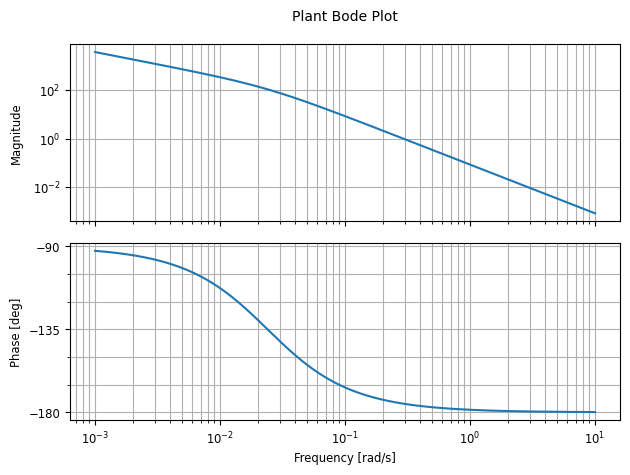

In [93]:
omega = np.logspace(-3, 1, 3000)
P.bode_plot(omega=omega, title='Plant Bode Plot')

### Designed Controller C(s)

In [94]:
# Controller:
# C(s) = K (s+a)^2 / [ s (tau s + 1) ]
C = K * (s + a)**2 / (s * (tau*s + 1))
C

TransferFunction(
array([ 71.69952772, 254.92630312, 226.59640201]),
array([9.e-04, 1.e+00, 0.e+00]),
outputs=1, inputs=1)

#### Display Bode Plot of Controller $C(s)$

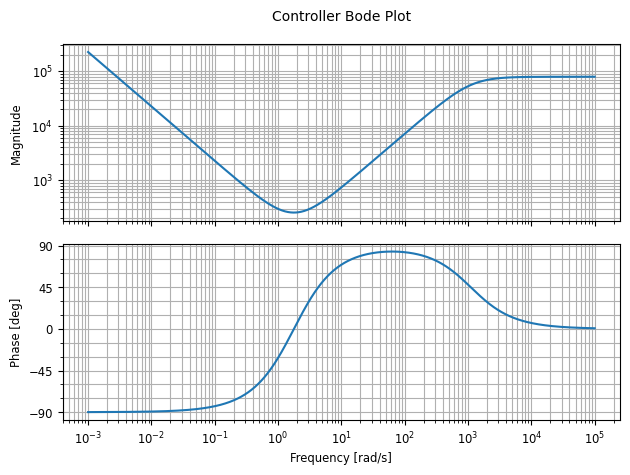

In [95]:
omega = np.logspace(-3, 5, 3000)
C.bode_plot(omega=omega, title='Controller Bode Plot')

### Display Loop Gain Transfer Function $L(s)=P(s) \times C(s)$

In [96]:
L = ct.minreal(C * P, verbose=False)
L

TransferFunction(
array([ 6915.81777887, 24589.05819341, 21856.48184249]),
array([1.00000000e+00, 1.11113508e+03, 2.66333333e+01, 0.00000000e+00,
       0.00000000e+00]),
outputs=1, inputs=1)

#### Display Bode Plot of Loop Gain Transfer Function $L(s)$

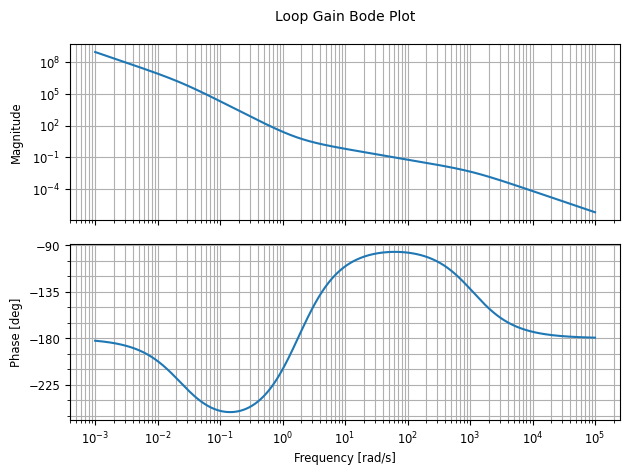

In [97]:
omega = np.logspace(-3, 5, 3000)
L.bode_plot(omega=omega, title='Loop Gain Bode Plot', wrap_phase=False)

### Display Complementary Sensitivity Transfer Function $T(s)$

In [98]:
T = ct.minreal(ct.feedback(L, 1), verbose=False)   # complementary sensitivity
T

TransferFunction(
array([ 6915.81777887, 24589.05819341, 21856.48184249]),
array([1.00000000e+00, 1.11113508e+03, 6.94245111e+03, 2.45890582e+04,
       2.18564818e+04]),
outputs=1, inputs=1)

#### Display Bode Plot of Complementary Sensitivty Transfer Function $T(s)$

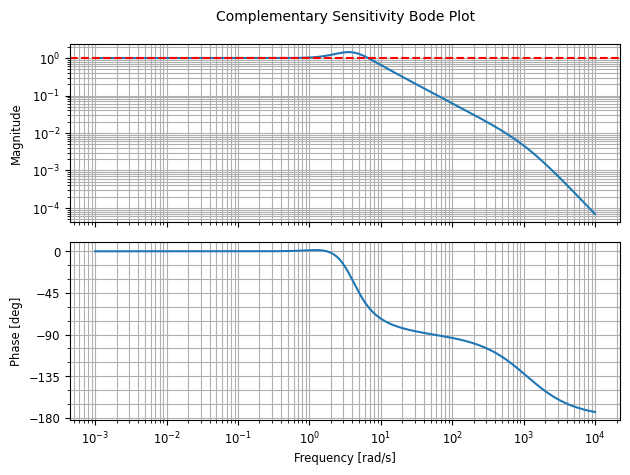

In [99]:
omega = np.logspace(-3, 4, 3000)
# Generate the Bode plot and get the figure/axes
T.bode_plot(omega=omega, 
            title='Complementary Sensitivity Bode Plot', 
            wrap_phase=True)

# Get the current figure and its axes
fig = plt.gcf()
axes = fig.axes   # This is usually a list with 2 axes: [magnitude, phase]

# axes[0] = magnitude plot (in dB)
mag_ax = axes[0]

# Add the 0 dB reference line (Gain = 1)
mag_ax.axhline(y=1, 
               color='red', 
               linestyle='--', 
               linewidth=1.5, 
               label='0 dB (Gain = 1)')

plt.tight_layout()
plt.show()

### Display Sensitivity Transfer Function $S(s)$

In [100]:
S = ct.minreal(1 / (1 + L), verbose=False)         # sensitivity
S

TransferFunction(
array([1.00000000e+00, 1.11113508e+03, 2.66333333e+01, 0.00000000e+00,
       0.00000000e+00]),
array([1.00000000e+00, 1.11113508e+03, 6.94245111e+03, 2.45890582e+04,
       2.18564818e+04]),
outputs=1, inputs=1)

#### Display Bode Plot of Sensitivty Transfer Function $S(s)$

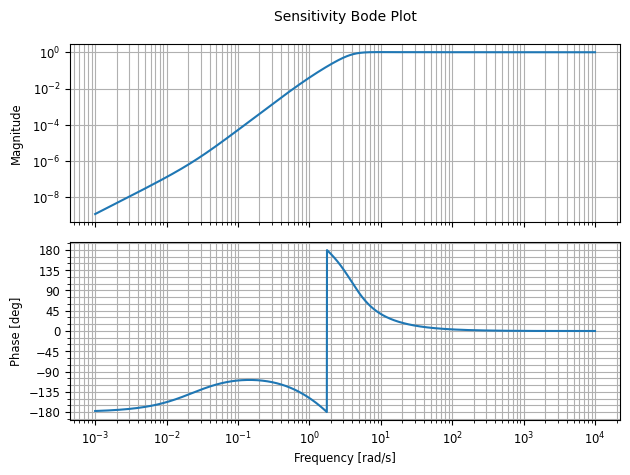

In [101]:
omega = np.logspace(-3, 4, 3000)
S.bode_plot(omega=omega, title='Sensitivity Bode Plot', wrap_phase=True)

### Display Gain Crossover Frequency in $[rad/sec]$

In [102]:
w_bw_target = 10.0
w_gc_target = w_bw_target / float(1.5)
w_gc_target

6.666666666666667

### Calculate Verfication Quantities

In [103]:
# Magnitude and phase at the chosen crossover
Ljw = ct.evalfr(L, 1j * w_gc_target)
mag_at_wgc = abs(Ljw)
mag_db_at_wgc = 20 * np.log10(mag_at_wgc)
phase_deg_at_wgc = np.degrees(np.angle(Ljw))

### Calculate Margins and Bandwidth

In [104]:
# Margins from python-control
gm, pm, wg, wp = ct.margin(L)   # wp = phase-margin crossover frequency
bw_closed = ct.bandwidth(T)

In [105]:
print("\n================ VERIFICATION ================\n")
print(f"Target closed-loop bandwidth          = {w_bw_target:.4f} rad/s")
print(f"Chosen crossover from design rule     = {w_gc_target:.4f} rad/s")
print(f"|L(jw_gc_target)|                     = {mag_at_wgc:.6f}")
print(f"20log10|L(jw_gc_target)|              = {mag_db_at_wgc:.6f} dB")
print(f"angle L(jw_gc_target)                 = {phase_deg_at_wgc:.6f} deg")
print(f"Phase margin from control.margin      = {pm:.6f} deg")
print(f"Phase-margin crossover frequency wp   = {wp:.6f} rad/s")
print(f"Gain margin crossover frequency wg    = {wg:.6f} rad/s")
print(f"Closed-loop bandwidth bandwidth(T)    = {bw_closed:.6f} rad/s")


================ VERIFICATION ================

Target closed-loop bandwidth          = 10.0000 rad/s
Chosen crossover from design rule     = 6.6667 rad/s
|L(jw_gc_target)|                     = 1.000000
20log10|L(jw_gc_target)|              = -0.000000 dB
angle L(jw_gc_target)                 = -120.000000 deg
Phase margin from control.margin      = 60.000000 deg
Phase-margin crossover frequency wp   = 6.666667 rad/s
Gain margin crossover frequency wg    = 1.756420 rad/s
Closed-loop bandwidth bandwidth(T)    = 9.291460 rad/s


### Build Plots

#### Frequency Grid

In [106]:
omega = np.logspace(-3, 4, 3000)

#### Bode Plot Helper Function

In [107]:
def bode_data(sys, omega):
    mag, phase, omega = ct.frequency_response(sys, omega)
    mag_db = 20 * np.log10(np.squeeze(mag))
    phase_deg = np.degrees(np.unwrap(np.squeeze(phase)))
    return omega, mag_db, phase_deg

### Controller Bode Plot

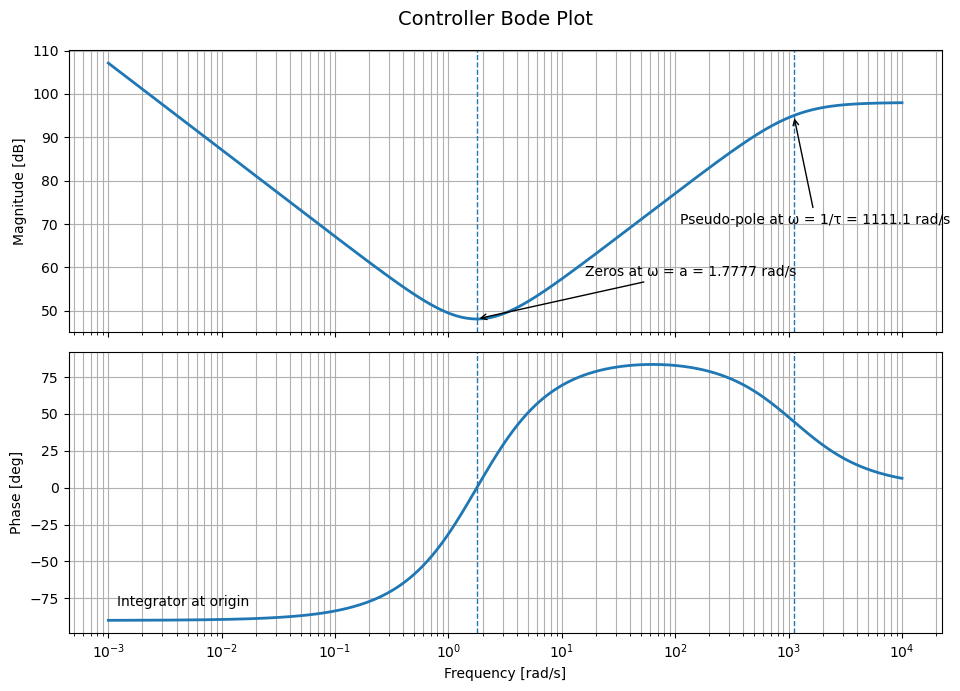

In [108]:
wc, magc_db, phasec_deg = bode_data(C, omega)

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Controller Bode Plot", fontsize=14)

ax[0].semilogx(wc, magc_db, linewidth=2)
ax[0].set_ylabel("Magnitude [dB]")
ax[0].grid(True, which='both')

ax[1].semilogx(wc, phasec_deg, linewidth=2)
ax[1].set_ylabel("Phase [deg]")
ax[1].set_xlabel("Frequency [rad/s]")
ax[1].grid(True, which='both')

# Annotate controller features:
# zeros at -a, integrator at 0, pseudo-pole at -1/tau
w_zero = a
w_pseudo = 1 / tau

for axes in ax:
    axes.axvline(w_zero, linestyle='--', linewidth=1)
    axes.axvline(w_pseudo, linestyle='--', linewidth=1)

ax[0].annotate(f'Zeros at ω = a = {w_zero:.4f} rad/s',
               xy=(w_zero, np.interp(w_zero, wc, magc_db)),
               xytext=(w_zero*9, np.interp(w_zero, wc, magc_db)+10),
               arrowprops=dict(arrowstyle='->'))

ax[0].annotate(rf'Pseudo-pole at ω = 1/$\tau$ = {w_pseudo:.1f} rad/s',
               xy=(w_pseudo, np.interp(w_pseudo, wc, magc_db)),
               xytext=(w_pseudo/10, np.interp(w_pseudo, wc, magc_db)-25),
               arrowprops=dict(arrowstyle='->'))

ax[1].text(1.2e-3, phasec_deg.min()+10, "Integrator at origin", fontsize=10)

plt.tight_layout()
plt.show()

### Controller Step Response

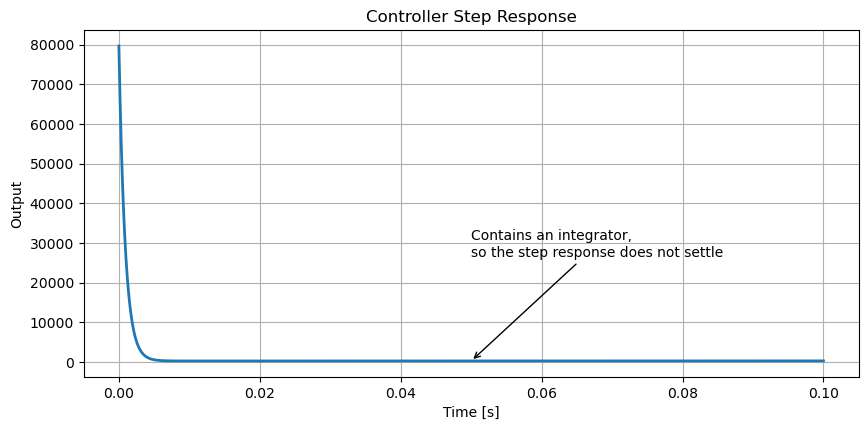

In [109]:
# Note: because C(s) contains an integrator, a step input causes
# the controller output to grow without bound.
# ============================================================
t_c = np.linspace(0, 0.1, 3000)
t1, y1 = ct.step_response(C, T=t_c)

plt.figure(figsize=(10, 4.5))
plt.plot(t1, y1, linewidth=2)
plt.title("Controller Step Response")
plt.xlabel("Time [s]")
plt.ylabel("Output")
plt.grid(True)

plt.annotate("Contains an integrator,\nso the step response does not settle",
             xy=(t1[len(t1)//2], y1[len(y1)//2]),
             xytext=(t1[len(t1)//2], y1[len(y1)//2] * 100),
             arrowprops=dict(arrowstyle='->'))

plt.show()

### Loop Gain (Open Loop) Bode Plot of $L(s)$

Plotted phase at wp: -120.00 deg


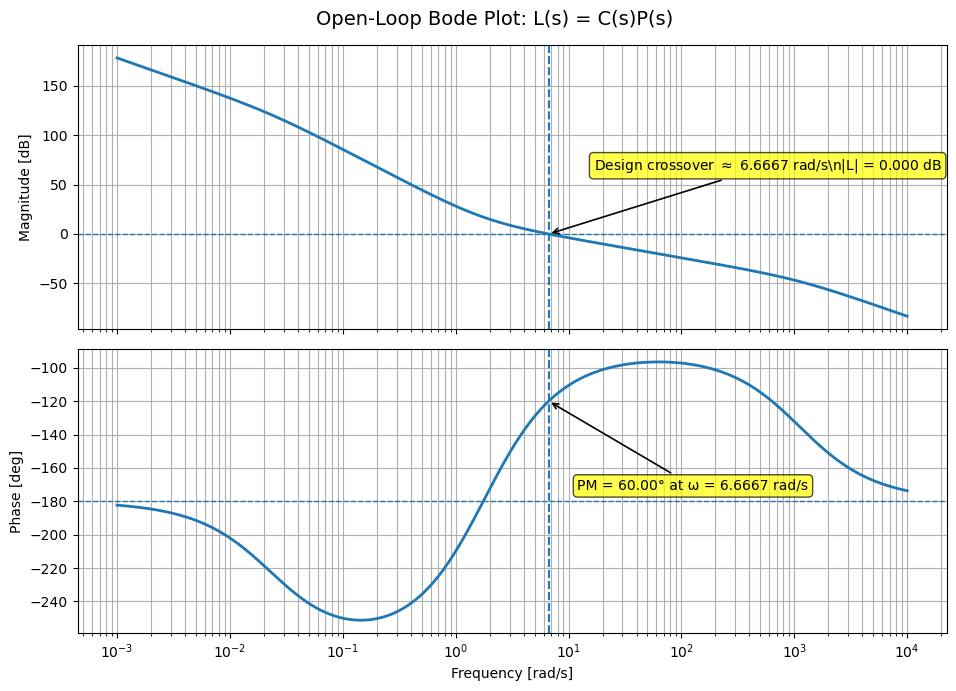

In [110]:
# Open-loop Bode plot with gain crossover and phase margin
wl, magl_db, phasel_deg = bode_data(L, omega)

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Open-Loop Bode Plot: L(s) = C(s)P(s)", fontsize=14)

ax[0].semilogx(wl, magl_db, linewidth=2)
ax[0].axhline(0, linestyle='--', linewidth=1)
ax[0].set_ylabel("Magnitude [dB]")
ax[0].grid(True, which='both')

ax[1].semilogx(wl, phasel_deg-360, linewidth=2)
ax[1].axhline(-180, linestyle='--', linewidth=1)
ax[1].set_ylabel("Phase [deg]")
ax[1].set_xlabel("Frequency [rad/s]")
ax[1].grid(True, which='both')

# Annotate design crossover and actual PM crossover
for axes in ax:
    axes.axvline(w_gc_target, linestyle=':', linewidth=1.5)
    if np.isfinite(wp) and wp > 0:
        axes.axvline(wp, linestyle='--', linewidth=1.5)

ax[0].annotate(rf'Design crossover $\approx$ {w_gc_target:.4f} rad/s\n|L| = {np.abs(mag_db_at_wgc):.3f} dB',
               xy=(w_gc_target, np.interp(w_gc_target, wl, magl_db)),
               xytext=(w_gc_target*2.5, np.interp(w_gc_target, wl, magl_db)+60),
               arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
               ha='left', va='bottom', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.7))

# === FIXED Phase Margin Annotation ===
if np.isfinite(wp) and wp > 0:
    # Use the ACTUAL plotted y-value (after -360 shift)
    plotted_phase_at_wp = np.interp(wp, wl, phasel_deg) - 360
    
    print(f"Plotted phase at wp: {plotted_phase_at_wp:.2f} deg")   # for debugging

    ax[1].annotate(f'PM = {pm:.2f}° at ω = {wp:.4f} rad/s',
                   xy=(wp, plotted_phase_at_wp),           # point on the curve
                   xytext=(wp * 1.8, plotted_phase_at_wp - 55),   # text position: right and slightly above
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                   ha='left', va='bottom', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

### Plot the Open Loop Step Response of $L(s)$

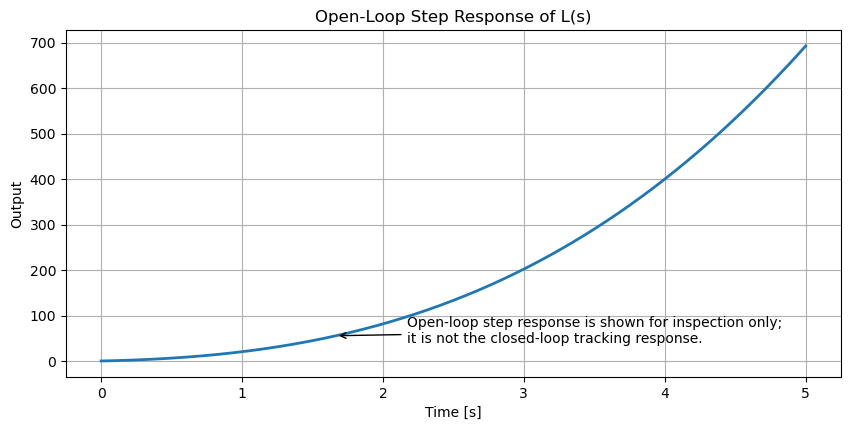

In [111]:
# Note: open-loop step response is not a closed-loop performance metric.
# Because the loop contains integrators, this response will not settle.
# ============================================================
t_l = np.linspace(0, 5, 3000)
t2, y2 = ct.step_response(L, T=t_l)

plt.figure(figsize=(10, 4.5))
plt.plot(t2, y2, linewidth=2)
plt.title("Open-Loop Step Response of L(s)")
plt.xlabel("Time [s]")
plt.ylabel("Output")
plt.grid(True)

plt.annotate("Open-loop step response is shown for inspection only;\nit is not the closed-loop tracking response.",
             xy=(t2[len(t2)//3], y2[len(y2)//3]),
             xytext=(t2[len(t2)//3] + 0.5, y2[len(y2)//3] * 0.7),
             arrowprops=dict(arrowstyle='->'))

plt.show()

### Complementary Sensitivity $T(s)$ Bode Plot

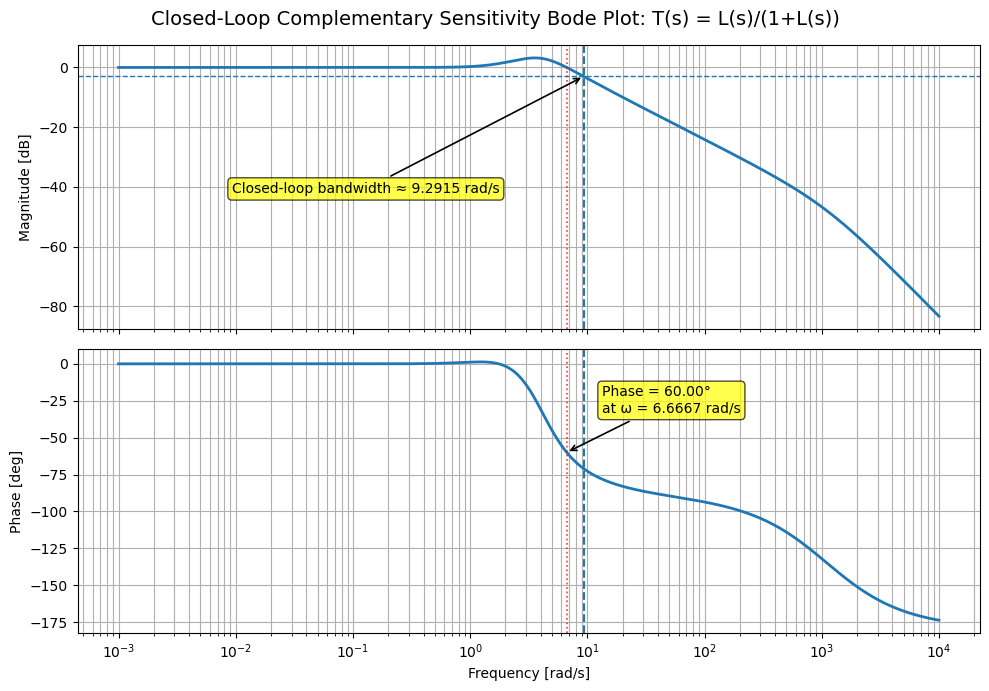

In [112]:
# ============================================================
# Closed-loop Bode plot to verify bandwidth
# T(s) = L/(1+L)
# ============================================================
wt, magt_db, phaset_deg = bode_data(T, omega)

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Closed-Loop Complementary Sensitivity Bode Plot: T(s) = L(s)/(1+L(s))", fontsize=14)

ax[0].semilogx(wt, magt_db, linewidth=2)
ax[0].axhline(-3, linestyle='--', linewidth=1)
ax[0].set_ylabel("Magnitude [dB]")
ax[0].grid(True, which='both')

ax[1].semilogx(wt, phaset_deg, linewidth=2)
ax[1].set_ylabel("Phase [deg]")
ax[1].set_xlabel("Frequency [rad/s]")
ax[1].grid(True, which='both')

if np.isfinite(bw_closed) and bw_closed > 0:
    for axes in ax:
        axes.axvline(bw_closed, linestyle='--', linewidth=1.5)

    ax[0].annotate(f'Closed-loop bandwidth ≈ {bw_closed:.4f} rad/s',
                   xy=(bw_closed, np.interp(bw_closed, wt, magt_db)),
                   xytext=(bw_closed/1000, np.interp(bw_closed, wt, magt_db)-40),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                   ha='left', va='bottom', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.7))

# ====================== Phase Annotation ======================
if np.isfinite(pm) and pm > 0 and np.isfinite(wp) and wp > 0:
    # Find the phase value on the plotted curve at ω = wp (phase crossover)
    phase_at_wp = np.interp(wp, wt, phaset_deg)
    
    ax[1].annotate(f'Phase = {pm:.2f}°\nat ω = {wp:.4f} rad/s',
                   xy=(wp, phase_at_wp),                    # point on the curve
                   xytext=(wp * 2.0, phase_at_wp + 25),     # text position: right and above
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                   ha='left', va='bottom', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.7))

    # Optional: add vertical line at phase crossover frequency
    for axes in ax:
        axes.axvline(wp, linestyle=':', linewidth=1.2, color='red', alpha=0.8)

plt.tight_layout()
plt.show()

### Sensitivity $S(s)$ Bode Plot

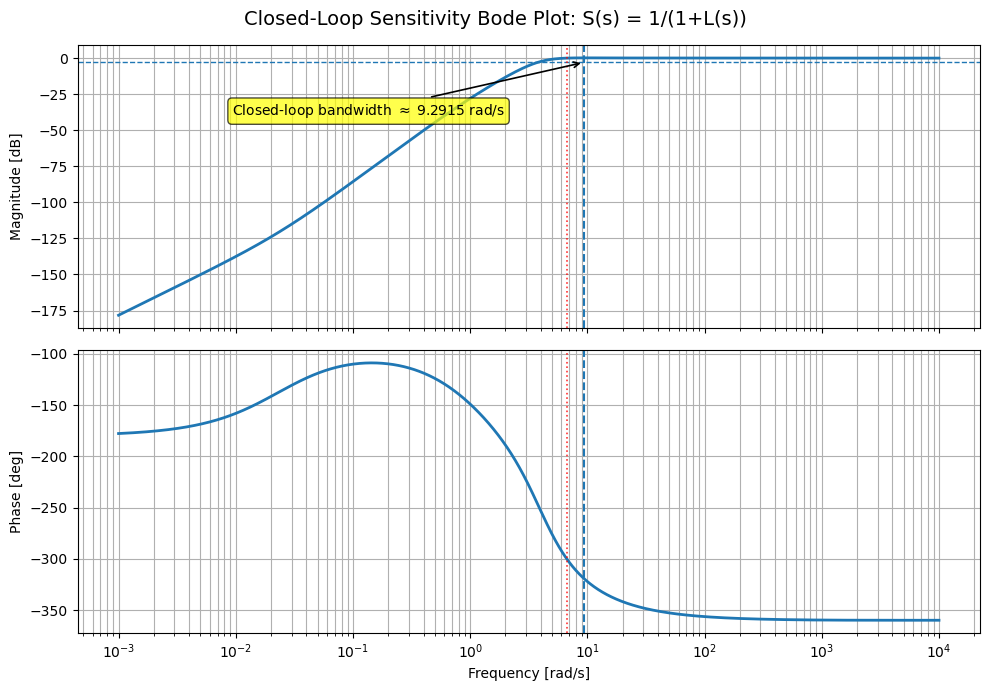

In [113]:
# ============================================================
# Closed-loop Bode plot to verify bandwidth
# S(s) = 1 /(1+L)
# ============================================================
ws, mags_db, phases_deg = bode_data(S, omega)

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Closed-Loop Sensitivity Bode Plot: S(s) = 1/(1+L(s))", fontsize=14)

ax[0].semilogx(ws, mags_db, linewidth=2)
ax[0].axhline(-3, linestyle='--', linewidth=1)
ax[0].set_ylabel("Magnitude [dB]")
ax[0].grid(True, which='both')

ax[1].semilogx(ws, phases_deg, linewidth=2)
ax[1].set_ylabel("Phase [deg]")
ax[1].set_xlabel("Frequency [rad/s]")
ax[1].grid(True, which='both')

if np.isfinite(bw_closed) and bw_closed > 0:
    for axes in ax:
        axes.axvline(bw_closed, linestyle='--', linewidth=1.5)

    ax[0].annotate(rf'Closed-loop bandwidth $\approx$ {bw_closed:.4f} rad/s',
                   xy=(bw_closed, np.interp(bw_closed, wt, magt_db)),
                   xytext=(bw_closed/1000, np.interp(bw_closed, wt, magt_db)-40),
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                   ha='left', va='bottom', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.7))

# ====================== Phase Annotation ======================
if np.isfinite(pm) and pm > 0 and np.isfinite(wp) and wp > 0:
    # Find the phase value on the plotted curve at ω = wp (phase crossover)
    phase_at_wp = np.interp(wp, wt, phaset_deg)
    
    ax[1].annotate(f'Phase = {pm:.2f}°\nat ω = {wp:.4f} rad/s',
                   xy=(wp, phase_at_wp),                    # point on the curve
                   xytext=(wp * 2.0, phase_at_wp + 25),     # text position: right and above
                   arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                   ha='left', va='bottom', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.7))

    # Optional: add vertical line at phase crossover frequency
    for axes in ax:
        axes.axvline(wp, linestyle=':', linewidth=1.2, color='red', alpha=0.8)

plt.tight_layout()
plt.show()

### Plot Closed Loop Step Response

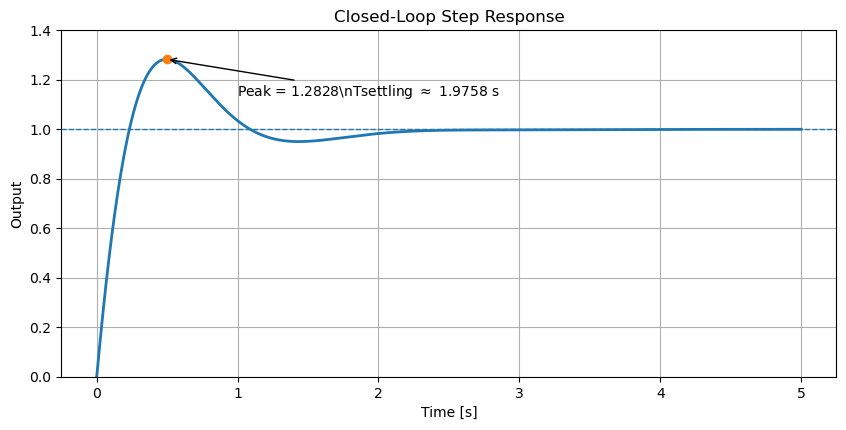


================ STEP INFO FOR CLOSED LOOP ================

RiseTime            : 0.16464658424747655
SettlingTime        : 1.9757590109697185
SettlingMin         : 0.9500992854912289
SettlingMax         : 1.2827329688449818
Overshoot           : 28.273296884498148
Undershoot          : 0.0
Peak                : 1.2827329688449818
PeakTime            : 0.4939397527424296
SteadyStateValue    : 1.0000000000000002


In [114]:
# ============================================================
# Closed-loop step response
# ============================================================
t_cl = np.linspace(0, 5, 3000)
t3, y3 = ct.step_response(T, T=t_cl)

info = ct.step_info(T)

plt.figure(figsize=(10, 4.5))
plt.plot(t3, y3, linewidth=2)
plt.axhline(1, linestyle='--', linewidth=1)
plt.title("Closed-Loop Step Response")
plt.xlabel("Time [s]")
plt.ylim(0, 1.4)
plt.ylabel("Output")
plt.grid(True)

peak_idx = np.argmax(y3)
plt.plot(t3[peak_idx], y3[peak_idx], 'o')
plt.annotate(rf"Peak = {y3[peak_idx]:.4f}\nTsettling $\approx$ {info['SettlingTime']:.4f} s",
             xy=(t3[peak_idx], y3[peak_idx]),
             xytext=(t3[peak_idx] + 0.5
                     , y3[peak_idx] - 0.15),
             arrowprops=dict(arrowstyle='->'))

plt.show()

print("\n================ STEP INFO FOR CLOSED LOOP ================\n")
for k, v in info.items():
    print(f"{k:20s}: {v}")

## Q6) What do you get for the step response when the step value is changed from he to he + 0.1 i.e change of 0.1m in liquid level? Discuss your observations.

Answer: The closed-loop response shows instability and is not similar to the clean closed-loop response seen in the answer to Q5.  As explained further in the description for Experiment 3.3, the instability is due to integrator windup.  The Controller's output increases by a considerable amount, which is clipped due to saturation in the Plant.  The Controller keeps adding command to the Plant, which the plant can not accomodate.  This leads to large overshoots and the appearance of instability.

## Q7) Did implementing the limited integrator solve the windup problem? Provide step response plots.

Answer: Yes, the limited integrator solved the windup problem.  This is clearly seen in the scope output of the limited integrator, where the output is limited to between 0.5 and -0.5.

## Experiment 3.4.1

Discretize your PID controller and test it in a closed loop in SIMULINK with the plant to verify it works. For sampling time use Ts = 0.01 sec. 

### Define symbols

In [115]:
s, z = sp.symbols('s z')
K_sym, a, tau, Ts = sp.symbols('K a tau T_s', positive=True, real=True)

### Define the Continuous-Time Controller

In [116]:
# C(s) = K (s+a)^2 / [ s (tau s + 1) ]

C_s = K_sym * (s + a)**2 / (s * (tau*s + 1))

display(Eq(sp.Symbol('C(s)'), C_s))

Eq(C(s), K*(a + s)**2/(s*(s*tau + 1)))

### Expand Numerator for Clarity

In [117]:
C_s_expanded = sp.simplify(K_sym * (s**2 + 2*a*s + a**2) / (s * (tau*s + 1)))
display(Eq(sp.Symbol('C(s)'), C_s_expanded))

Eq(C(s), K*(a**2 + 2*a*s + s**2)/(s*(s*tau + 1)))

### Tustin Substitution

In [118]:
# s -> (2/Ts) * (z-1)/(z+1)

s_tustin = (sp.Integer(2) / Ts) * ((z - 1) / (z + 1))

display(Eq(sp.Symbol(r's_{\text{Tustin}}'), s_tustin))

Eq(s_{\text{Tustin}}, 2*(z - 1)/(T_s*(z + 1)))

### Substitute into $C(s)$

In [119]:
C_z_sub = sp.simplify(C_s.subs(s, s_tustin))
display(Eq(sp.Symbol('C(z)'), C_z_sub))

Eq(C(z), K*(T_s*a*(z + 1) + 2*z - 2)**2/(2*(z - 1)*(T_s*(z + 1) + 2*tau*(z - 1))))

### Introduce $q = (z-1)/(z+1)$

In [120]:
q = sp.symbols('q')

C_q = sp.simplify(C_s.subs(s, (sp.Integer(2)/Ts) * q))
display(Eq(sp.Symbol('q'), (z - 1)/(z + 1)))
display(Eq(sp.Symbol('C(q)'), C_q))

Eq(q, (z - 1)/(z + 1))

Eq(C(q), K*(T_s*a + 2*q)**2/(2*q*(T_s + 2*q*tau)))

### Substitute Numerical Values Used in the Lab

In [121]:
# K = 71.699528, a = 1.7777, tau = 0.0009, Ts = 0.01

vals = {
    K_sym: sp.Float('71.699528'),
    a: sp.Float('1.7777'),
    tau: sp.Float('0.0009'),
    Ts: sp.Float('0.01')
}

C_q_num = sp.simplify(C_q.subs(vals))
display(Eq(sp.Symbol('C(q)'), C_q_num))

Eq(C(q), 35.849764*(2*q + 0.017777)**2/(q*(0.0018*q + 0.01)))

### Expand the Tustin Scaling Terms  

In [122]:
# 2/Ts = 200, tau*(2/Ts) = 0.18

two_over_Ts = sp.simplify((sp.Integer(2)/Ts).subs(vals))

In [123]:
tau_two_over_Ts = sp.simplify((tau * (sp.Integer(2)/Ts)).subs(vals))

In [124]:
display(Eq(sp.Symbol(r'2/T_s'), two_over_Ts))
display(Eq(sp.Symbol(r'2\tau/T_s'), tau_two_over_Ts))

Eq(2/T_s, 200.0)

Eq(2\tau/T_s, 0.18)

In [125]:
C_q_num_manual = sp.Float('71.699528') * (sp.Float('200')*q + sp.Float('1.7777'))**2 / (
    sp.Float('200')*q * (sp.Float('0.18')*q + 1)
)

display(Eq(sp.Symbol('C(q)'), sp.simplify(C_q_num_manual)))

Eq(C(q), 0.35849764*(200.0*q + 1.7777)**2/(q*(0.18*q + 1)))

### Replace $q = (z-1)/(z+1)$

In [126]:
C_z = sp.simplify(C_q_num_manual.subs(q, (z - 1)/(z + 1)))
display(Eq(sp.Symbol('C(z)'), C_z))

Eq(C(z), 0.35849764*(201.7777*z - 198.2223)**2/((z - 1)*(1.18*z + 0.82)))

### Show Intermediate Steps

In [127]:
term1 = sp.simplify((sp.Float('200')*q + sp.Float('1.7777')).subs(q, (z - 1)/(z + 1)))
term2 = sp.simplify((sp.Float('0.18')*q + 1).subs(q, (z - 1)/(z + 1)))
term3 = sp.simplify((sp.Float('200')*q).subs(q, (z - 1)/(z + 1)))

display(Eq(sp.Symbol(r'200q + 1.7777'), term1))
display(Eq(sp.Symbol(r'0.18q + 1'), term2))
display(Eq(sp.Symbol(r'200q'), term3))

Eq(200q + 1.7777, (201.7777*z - 198.2223)/(z + 1))

Eq(0.18q + 1, (1.18*z + 0.82)/(z + 1))

Eq(200q, 200.0*(z - 1)/(z + 1))

### Write $C(z)$ as a Rational Function in $z$

In [128]:
C_z_together = sp.together(C_z)
display(Eq(sp.Symbol('C(z)'), C_z_together))

Eq(C(z), 0.35849764*(201.7777*z - 198.2223)**2/((z - 1)*(1.18*z + 0.82)))

### Expand the Numerator and Denominator

In [129]:
num_z, den_z = sp.fraction(C_z_together)
num_z = sp.expand(num_z)
den_z = sp.expand(den_z)

display(Eq(sp.Symbol('Numerator\; in\; z'), num_z))
display(Eq(sp.Symbol('Denominator\; in\; z'), den_z))

Eq(Numerator\; in\; z, 14595.9590322916*z**2 - 28677.5453391193*z + 14086.1180285891)

Eq(Denominator\; in\; z, 1.18*z**2 - 0.36*z - 0.82)

### Normalize Denominator Leading Coefficient

In [130]:
den_poly = sp.Poly(den_z, z)
lead_coeff = den_poly.LC()

num_z_norm = sp.expand(num_z / lead_coeff)
den_z_norm = sp.expand(den_z / lead_coeff)

display(Eq(sp.Symbol('Leading\; denominator\; coefficient'), lead_coeff))
display(Eq(sp.Symbol('Normalized\; numerator'), num_z_norm))
display(Eq(sp.Symbol('Normalized\; denominator'), den_z_norm))

Eq(Leading\; denominator\; coefficient, 1.18)

Eq(Normalized\; numerator, 12369.4568070267*z**2 - 24303.0045246774*z + 11937.3881598213)

Eq(Normalized\; denominator, 1.0*z**2 - 0.305084745762712*z - 0.694915254237288)

### Convert to $z^{-1}$ Form

In [131]:
# Divide numerator and denominator by z^2
num_zinv = sp.expand(num_z_norm / z**2)
den_zinv = sp.expand(den_z_norm / z**2)

display(Eq(sp.Symbol('Numerator\; in\; z^{-1}\; form'), num_zinv))
display(Eq(sp.Symbol('Denominator\; in\; z^{-1}\; form'), den_zinv))

Eq(Numerator\; in\; z^{-1}\; form, 12369.4568070267 - 24303.0045246774/z + 11937.3881598213/z**2)

Eq(Denominator\; in\; z^{-1}\; form, 1.0 - 0.305084745762712/z - 0.694915254237288/z**2)

### Discrete Transfer Function Form

In [132]:
C_zinv = sp.simplify(num_zinv / den_zinv)
display(Eq(sp.Symbol('C(z)'), C_zinv))

Eq(C(z), (-12369.4568070267*z**2 + 24303.0045246774*z - 11937.3881598213)/(-1.0*z**2 + 0.305084745762712*z + 0.694915254237288))

### Results Summary

In [133]:
print("\n================ CONTINUOUS CONTROLLER ================\n")
display(C_s)

print("\n================ TUSTIN SUBSTITUTION ================\n")
display(s_tustin)

print("\n================ DISCRETE CONTROLLER C(z) ================\n")
display(C_z_together)

print("\n================ NORMALIZED FORM IN z ================\n")
print("Numerator:")
display(num_z_norm)
print("\nDenominator:")
display(den_z_norm)

print("\n================ z^{-1} FORM ================\n")
print("Numerator:")
display(num_zinv)
print("\nDenominator:")
display(den_zinv)

print("\n================ DISCRETE CONTRROLLER TF FORM ================\n")
display(C_zinv)


================ CONTINUOUS CONTROLLER ================



K*(a + s)**2/(s*(s*tau + 1))


================ TUSTIN SUBSTITUTION ================



2*(z - 1)/(T_s*(z + 1))


================ DISCRETE CONTROLLER C(z) ================



...

12369.4568070267 - 24303.0045246774/z + 11937.3881598213/z**2


Denominator:


1.0 - 0.305084745762712/z - 0.694915254237288/z**2


================ DISCRETE CONTRROLLER TF FORM ================



(-12369.4568070267*z**2 + 24303.0045246774*z - 11937.3881598213)/(-1.0*z**2 + 0.305084745762712*z + 0.694915254237288)

## Verify with Control System Library

### Define Continuous Time Controller

In [134]:
# C(s) = K (s+a)^2 / [ s (tau*s + 1) ]

K = 71.699528
a = 1.7777
tau = 0.0009
Ts = 0.01

s = ct.tf('s')

C_s = K * (s + a)**2 / (s * (tau*s + 1))

print("\n================ CONTINUOUS-TIME CONTROLLER C(s) ================\n")
C_s


================ CONTINUOUS-TIME CONTROLLER C(s) ================



TransferFunction(
array([ 71.699528  , 254.92050185, 226.58608807]),
array([9.e-04, 1.e+00, 0.e+00]),
outputs=1, inputs=1)

### Discretize using Tustin

In [135]:
# In python-control, 'tustin' and 'bilinear' are supported.

C_z_tustin = ct.c2d(C_s, Ts, method='tustin')

print("\n================ DISCRETE-TIME CONTROLLER C(z) VIA TUSTIN ================\n")
C_z_tustin


================ DISCRETE-TIME CONTROLLER C(z) VIA TUSTIN ================



TransferFunction(
array([ 12369.45680703, -24303.00452468,  11937.38815982]),
array([ 1.        , -0.30508475, -0.69491525]),
dt=0.01,
name='sys[69]$sampled', outputs=1, inputs=1)

In [136]:
w_gc = 10 / 1.5   # ~6.6667 rad/s

C_z_prewarp = ct.c2d(C_s, Ts, method='tustin', prewarp_frequency=w_gc)

print("\n================ TUSTIN WITH PREWARP ================\n")
C_z_prewarp


================ TUSTIN WITH PREWARP ================



TransferFunction(
array([ 12365.65459366, -24295.374044  ,  11933.56153261]),
array([ 1.        , -0.30498898, -0.69501102]),
dt=0.01,
name='sys[69]$sampled', outputs=1, inputs=1)

### Get Numerator and Denominator Coefficients

In [137]:
num = np.squeeze(C_z_tustin.num[0][0])
den = np.squeeze(C_z_tustin.den[0][0])

print("\nNumerator coefficients:")
num


Numerator coefficients:


array([ 12369.45680703, -24303.00452468,  11937.38815982])

In [138]:
print("\nDenominator coefficients:")
den


Denominator coefficients:


array([ 1.        , -0.30508475, -0.69491525])

## Bode Plots of $C(s)$ and $C_{Tustin}(z)$

Continuous-time controller C(s):


TransferFunction(
array([ 71.699528  , 254.92050185, 226.58608807]),
array([9.e-04, 1.e+00, 0.e+00]),
outputs=1, inputs=1)


Discrete-time controller C(z) via Tustin:


TransferFunction(
array([ 12369.45680703, -24303.00452468,  11937.38815982]),
array([ 1.        , -0.30508475, -0.69491525]),
dt=0.01,
name='sys[84]$sampled', outputs=1, inputs=1)

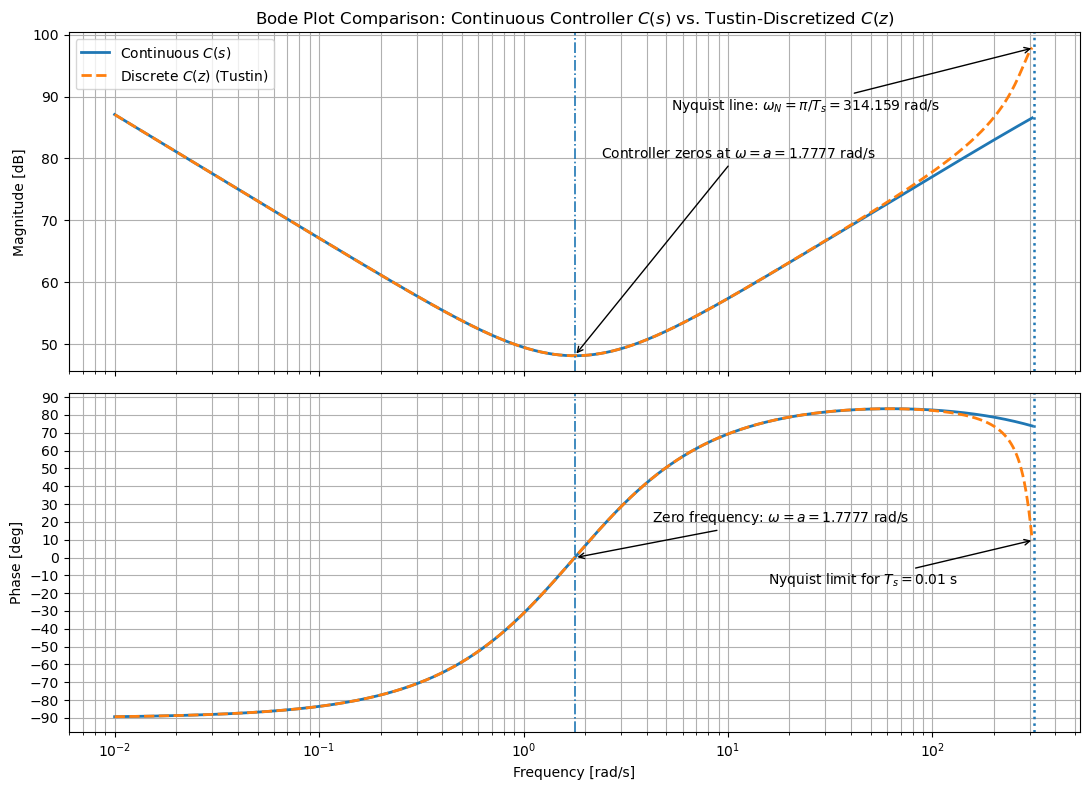

In [139]:
# ============================================================
# Controller parameters
# ============================================================
K = 71.699528
a = 1.7777
tau = 0.0009
Ts = 0.01

# ============================================================
# Define continuous-time controller C(s)
# C(s) = K (s+a)^2 / [ s (tau*s + 1) ]
# ============================================================
s = ct.tf('s')
C_s = K * (s + a)**2 / (s * (tau*s + 1))

# ============================================================
# Discretize with Tustin to get C(z)
# ============================================================
C_z = ct.c2d(C_s, Ts, method='tustin')

print("Continuous-time controller C(s):")
display(C_s)

print("\nDiscrete-time controller C(z) via Tustin:")
display(C_z)

# ============================================================
# Frequency range
# For comparison, only plot up to a bit below Nyquist
# ============================================================
w_nyq = np.pi / Ts                    # Nyquist frequency [rad/s]
w_min = 1e-2
w_max = 0.98 * w_nyq
omega = np.logspace(np.log10(w_min), np.log10(w_max), 3000)

# ============================================================
# Frequency responses
# Use the same omega grid for both C(s) and C(z)
# ============================================================
mag_s, phase_s, omega_s = ct.frequency_response(C_s, omega)
mag_z, phase_z, omega_z = ct.frequency_response(C_z, omega)

mag_s = np.squeeze(mag_s)
mag_z = np.squeeze(mag_z)

# unwrap phase so both curves are readable
phase_s_deg = np.degrees(np.unwrap(np.squeeze(phase_s)))
phase_z_deg = np.degrees(np.unwrap(np.squeeze(phase_z)))

mag_s_db = 20 * np.log10(mag_s)
mag_z_db = 20 * np.log10(mag_z)

# ============================================================
# Useful frequencies for annotations
# ============================================================
w_zero = a
w_pseudo = 1 / tau

# helper for interpolation in log-frequency domain
def interp_logx(x, xp, fp):
    return np.interp(np.log10(x), np.log10(xp), fp)

# values for annotations
mag_s_zero = interp_logx(w_zero, omega, mag_s_db)
mag_s_pseudo = interp_logx(min(w_pseudo, omega[-1]), omega, mag_s_db)

phase_s_zero = interp_logx(w_zero, omega, phase_s_deg)
phase_s_pseudo = interp_logx(min(w_pseudo, omega[-1]), omega, phase_s_deg)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# ---------------- Magnitude ----------------
ax[0].semilogx(omega, mag_s_db, linewidth=2, label=r'Continuous $C(s)$')
ax[0].semilogx(omega, mag_z_db, linewidth=2, linestyle='--', label=r'Discrete $C(z)$ (Tustin)')

ax[0].axvline(w_nyq, linestyle=':', linewidth=1.8)
ax[0].axvline(w_zero, linestyle='-.', linewidth=1.2)
if w_pseudo < omega[-1]:
    ax[0].axvline(w_pseudo, linestyle='-.', linewidth=1.2)

ax[0].set_ylabel('Magnitude [dB]')
ax[0].set_title('Bode Plot Comparison: Continuous Controller $C(s)$ vs. Tustin-Discretized $C(z)$')
ax[0].grid(True, which='both')
ax[0].legend()

ax[0].annotate(
    rf'Controller zeros at $\omega=a={w_zero:.4f}$ rad/s',
    xy=(w_zero, mag_s_zero),
    xytext=(w_zero * 1.35, mag_s_zero + 32),
    arrowprops=dict(arrowstyle='->')
)

if w_pseudo < omega[-1]:
    ax[0].annotate(
        rf'Pseudo-pole at $\omega=1/\tau={w_pseudo:.1f}$ rad/s',
        xy=(w_pseudo, mag_s_pseudo),
        xytext=(w_pseudo / 5, mag_s_pseudo - 18),
        arrowprops=dict(arrowstyle='->')
    )

ax[0].annotate(
    rf'Nyquist line: $\omega_N=\pi/T_s={w_nyq:.3f}$ rad/s',
    xy=(w_nyq, interp_logx(w_nyq * 0.98, omega, mag_z_db)),
    xytext=(w_nyq / 60, interp_logx(w_nyq * 0.98, omega, mag_z_db) - 10),
    arrowprops=dict(arrowstyle='->')
)

# ---------------- Phase ----------------
ax[1].semilogx(omega, phase_s_deg, linewidth=2, label=r'Continuous $C(s)$')
ax[1].semilogx(omega, phase_z_deg, linewidth=2, linestyle='--', label=r'Discrete $C(z)$ (Tustin)')

ax[1].axvline(w_nyq, linestyle=':', linewidth=1.8)
ax[1].axvline(w_zero, linestyle='-.', linewidth=1.2)
if w_pseudo < omega[-1]:
    ax[1].axvline(w_pseudo, linestyle='-.', linewidth=1.2)

ax[1].set_xlabel('Frequency [rad/s]')
ax[1].set_ylabel('Phase [deg]')
ax[1].grid(True, which='both')

# more phase tick marks
phase_min = min(np.nanmin(phase_s_deg), np.nanmin(phase_z_deg))
phase_max = max(np.nanmax(phase_s_deg), np.nanmax(phase_z_deg))
yt_lo = 10 * np.floor(phase_min / 10)
yt_hi = 10 * np.ceil(phase_max / 10)
ax[1].set_yticks(np.arange(yt_lo, yt_hi + 10, 10))

ax[1].annotate(
    rf'Zero frequency: $\omega=a={w_zero:.4f}$ rad/s',
    xy=(w_zero, phase_s_zero),
    xytext=(w_zero * 2.4, phase_s_zero + 20),
    arrowprops=dict(arrowstyle='->')
)

if w_pseudo < omega[-1]:
    ax[1].annotate(
        rf'Pseudo-pole: $\omega=1/\tau={w_pseudo:.1f}$ rad/s',
        xy=(w_pseudo, phase_s_pseudo),
        xytext=(w_pseudo / 6, phase_s_pseudo - 35),
        arrowprops=dict(arrowstyle='->')
    )

ax[1].annotate(
    rf'Nyquist limit for $T_s={Ts}$ s',
    xy=(w_nyq, interp_logx(w_nyq * 0.98, omega, phase_z_deg)),
    xytext=(w_nyq / 20, interp_logx(w_nyq * 0.98, omega, phase_z_deg) - 25),
    arrowprops=dict(arrowstyle='->')
)

plt.tight_layout()
plt.show()

## Parallel PID Discretization using Tustin / Bilinear Transform

### Define Symbols

In [140]:
s, z = sp.symbols('s z', complex=True)
K, a, tau, Ts = sp.symbols('K a tau T_s', positive=True, real=True)

# Parallel PID symbols
kp, ki, kd, N = sp.symbols('k_p k_i k_d N', real=True)

### Controller Transfer Function $C(s)$

In [141]:
# C(s) = K (s+a)^2 / [ s (tau s + 1) ]

C_s = sp.simplify(K * (s + a)**2 / (s * (tau*s + 1)))
display(Eq(sp.Symbol('C(s)'), C_s))

Eq(C(s), K*(a + s)**2/(s*(s*tau + 1)))

### Expand Numberator of $C(s)$

In [142]:
C_s_expanded = sp.simplify(K * (s**2 + 2*a*s + a**2) / (s * (tau*s + 1)))
display(Eq(sp.Symbol('C(s)'), C_s_expanded))

Eq(C(s), K*(a**2 + 2*a*s + s**2)/(s*(s*tau + 1)))

### Write Continuous Controller Transfer Function $C(s)$ in Filtered Parallel PID Form

In [143]:
# C(s) = kp + ki/s + kd * (N s)/(s+N)

C_parallel_s = kp + ki/s + kd * (N*s)/(s + N)
display(Eq(sp.Symbol('C_{parallel}(s)'), C_parallel_s))

Eq(C_{parallel}(s), N*k_d*s/(N + s) + k_i/s + k_p)

### Put Filtered Parallel PID Form over Common Denominator

In [144]:
C_parallel_common = sp.simplify(sp.together(C_parallel_s))
display(Eq(sp.Symbol('C_{parallel}(s)'), C_parallel_common))

Eq(C_{parallel}(s), (N*k_d*s**2 + k_i*(N + s) + k_p*s*(N + s))/(s*(N + s)))

### Isolate Numerator and Denominator

In [145]:
num_par, den_par = sp.fraction(C_parallel_common)
num_par = sp.expand(num_par)
den_par = sp.expand(den_par)

display(Eq(sp.Symbol('Numerator_{parallel}(s)'), num_par))
display(Eq(sp.Symbol('Denominator_{parallel}(s)'), den_par))

Eq(Numerator_{parallel}(s), N*k_d*s**2 + N*k_i + N*k_p*s + k_i*s + k_p*s**2)

Eq(Denominator_{parallel}(s), N*s + s**2)

### Setup Coefficient Matching

In [146]:
# Continuous controller:
# C(s) = K(s+a)^2 / [s(tau*s + 1)]
#
# Parallel filtered PID:
# C(s) = kp + ki/s + kd*(N*s)/(s+N), with N = 1/tau

C_parallel_tau = sp.simplify(C_parallel_s.subs(N, 1/tau))
display(Eq(sp.Symbol('C_{parallel}(s)'), C_parallel_tau))

Eq(C_{parallel}(s), k_d*s/(tau*(s + 1/tau)) + k_i/s + k_p)

In [147]:
C_parallel_tau_common = sp.simplify(sp.together(C_parallel_tau))
display(Eq(sp.Symbol('C_{parallel}(s)'), C_parallel_tau_common))

Eq(C_{parallel}(s), (k_d*s**2 + k_i*(s*tau + 1) + k_p*s*(s*tau + 1))/(s*(s*tau + 1)))

In [148]:
num_tau, den_tau = sp.fraction(C_parallel_tau_common)
num_tau = sp.expand(num_tau)
den_tau = sp.expand(den_tau)

display(Eq(sp.Symbol('Numerator_{parallel}(s)'), num_tau))
display(Eq(sp.Symbol('Denominator_{parallel}(s)'), den_tau))

Eq(Numerator_{parallel}(s), k_d*s**2 + k_i*s*tau + k_i + k_p*s**2*tau + k_p*s)

Eq(Denominator_{parallel}(s), s**2*tau + s)

In [149]:
target_num = sp.expand(K * (s + a)**2)
display(Eq(sp.Symbol('Targe\; numerator'), target_num))

Eq(Targe\; numerator, K*a**2 + 2*K*a*s + K*s**2)

#### Collect Coefficients in $s$

In [150]:
poly_num_tau = sp.Poly(num_tau, s)
poly_target = sp.Poly(target_num, s)

display(sp.Symbol('Parallel\; coeffs'),sp.Matrix(poly_num_tau.all_coeffs()))
display(sp.Symbol('Target\; coeffs'), sp.Matrix(poly_target.all_coeffs()))

Parallel\; coeffs

Matrix([
[k_d + k_p*tau],
[k_i*tau + k_p],
[          k_i]])

Target\; coeffs

Matrix([
[     K],
[ 2*K*a],
[K*a**2]])

### Perform Coefficient Matching

In [151]:
coeff_eqs = [
    sp.Eq(poly_num_tau.all_coeffs()[0], poly_target.all_coeffs()[0]),  # s^2
    sp.Eq(poly_num_tau.all_coeffs()[1], poly_target.all_coeffs()[1]),  # s^1
    sp.Eq(poly_num_tau.all_coeffs()[2], poly_target.all_coeffs()[2]),  # s^0
]

sol_pid = sp.solve(coeff_eqs, (kp, ki, kd), dict=True)[0]

kp_expr = sp.simplify(sol_pid[kp])
ki_expr = sp.simplify(sol_pid[ki])
kd_expr = sp.simplify(sol_pid[kd])

display(Eq(kp, kp_expr))
display(Eq(ki, ki_expr))
display(Eq(kd, kd_expr))

Eq(k_p, K*a*(-a*tau + 2))

Eq(k_i, K*a**2)

Eq(k_d, K*(a**2*tau**2 - 2*a*tau + 1))

### Perform Tustin Substitution

In [152]:
# s -> (2/Ts) * (z-1)/(z+1)

s_tustin = sp.simplify((sp.Integer(2)/Ts) * (z - 1)/(z + 1))
display(Eq(sp.Symbol(r's_{Tustin}'), s_tustin))

Eq(s_{Tustin}, 2*(z - 1)/(T_s*(z + 1)))

#### Perform Tustin Substitution for Proportional Branch

In [153]:
C_P_z = kp_expr
display(Eq(sp.Symbol('C_{P}(z)'), C_P_z))

Eq(C_{P}(z), K*a*(-a*tau + 2))

#### Perform Tustin Substitution for Integral Branch

In [154]:
C_I_s = ki_expr / s
display(Eq(sp.Symbol('C_{I}(s)'), C_I_s))

C_I_z = sp.simplify(C_I_s.subs(s, s_tustin))
display(Eq(sp.Symbol('C_{I}(z)'), C_I_z))

Eq(C_{I}(s), K*a**2/s)

Eq(C_{I}(z), K*T_s*a**2*(z + 1)/(2*(z - 1)))

In [155]:
# Show the standard closed form
C_I_z_closed = sp.simplify(ki_expr * (Ts/sp.Integer(2)) * (z + 1)/(z - 1))
display(Eq(sp.Symbol('C_{I}(z)'), C_I_z_closed))

Eq(C_{I}(z), K*T_s*a**2*(z + 1)/(2*(z - 1)))

#### Perform Tustin Substitution for Derivative Branch

In [156]:
C_D_s = kd_expr * ((1/tau) * s) / (s + 1/tau)
display(Eq(sp.Symbol('C_{D}(s)'), C_D_s))

Eq(C_{D}(s), K*s*(a**2*tau**2 - 2*a*tau + 1)/(tau*(s + 1/tau)))

In [157]:
C_D_z = sp.simplify(C_D_s.subs(s, s_tustin))
display(Eq(sp.Symbol('C_{D}(z)'), C_D_z))

Eq(C_{D}(z), 2*K*(z - 1)*(a**2*tau**2 - 2*a*tau + 1)/(T_s*(z + 1) + 2*tau*(z - 1)))

### Simplify the Derivative Branch into Standard Rational Form

In [158]:
C_D_z_together = sp.simplify(sp.together(C_D_z))
display(Eq(sp.Symbol('C_D(z)'), C_D_z_together))

num_Dz, den_Dz = sp.fraction(C_D_z_together)
num_Dz = sp.expand(num_Dz)
den_Dz = sp.expand(den_Dz)

display(Eq(sp.Symbol('Numerator_{D}(z)'), num_Dz))
display(Eq(sp.Symbol('Denominator_{D}(z)'), den_Dz))

Eq(C_D(z), 2*K*(z - 1)*(a**2*tau**2 - 2*a*tau + 1)/(T_s*(z + 1) + 2*tau*(z - 1)))

Eq(Numerator_{D}(z), 2*K*a**2*tau**2*z - 2*K*a**2*tau**2 - 4*K*a*tau*z + 4*K*a*tau + 2*K*z - 2*K)

Eq(Denominator_{D}(z), T_s*z + T_s + 2*tau*z - 2*tau)

### Assemble the Exact Tustin Parallel PID

In [159]:
C_parallel_z = sp.simplify(C_P_z + C_I_z_closed + C_D_z_together)
display(Eq(sp.Symbol('C_{parallel,Tustin}(z)'), C_parallel_z))

# Show the branch sum explicitly
display(Eq(sp.Symbol('C(z)'), sp.Symbol('C_P(z)') + sp.Symbol('C_I(z)') + sp.Symbol('C_D(z)')))

Eq(C_{parallel,Tustin}(z), K*(T_s**2*a**2*z**2 + 2*T_s**2*a**2*z + T_s**2*a**2 + 4*T_s*a*z**2 - 4*T_s*a + 4*z**2 - 8*z + 4)/(2*(T_s*z**2 - T_s + 2*tau*z**2 - 4*tau*z + 2*tau)))

Eq(C(z), C_D(z) + C_I(z) + C_P(z))

### Verify Correctness of Controller Discretization

In [160]:
C_full_tustin = sp.simplify(C_s.subs(s, s_tustin))
display(Eq(sp.Symbol('C_{full,Tustin}(z)'), C_full_tustin))

Eq(C_{full,Tustin}(z), K*(T_s*a*(z + 1) + 2*z - 2)**2/(2*(z - 1)*(T_s*(z + 1) + 2*tau*(z - 1))))

In [161]:
# Difference should be zero for exact Tustin-based parallel realization
verification = sp.simplify(sp.together(C_parallel_z - C_full_tustin))
display(Eq(sp.Symbol('C_{parallel,Tustin}(z) - C_{full,Tustin}(z)'), verification))

Eq(C_{parallel,Tustin}(z) - C_{full,Tustin}(z), 0)

### Substitute Numerical Values

In [162]:
vals = {
    K: sp.Float('71.699528'),
    a: sp.Float('1.7777'),
    tau: sp.Float('0.0009'),
    Ts: sp.Float('0.01'),
}

In [163]:
kp_num = sp.N(kp_expr.subs(vals))
ki_num = sp.N(ki_expr.subs(vals))
kd_num = sp.N(kd_expr.subs(vals))
N_num = sp.N((1/tau).subs(vals))

C_P_num = sp.N(C_P_z.subs(vals))
C_I_num = sp.simplify(C_I_z_closed.subs(vals))
C_D_num = sp.simplify(C_D_z_together.subs(vals))
C_total_num = sp.simplify(C_parallel_z.subs(vals))

display(Eq(kp, kp_num))
display(Eq(ki, ki_num))
display(Eq(kd, kd_num))
display(Eq(N, N_num))

display(Eq(sp.Symbol('C_P(z)'), C_P_num))
display(Eq(sp.Symbol('C_I(z)'), C_I_num))
display(Eq(sp.Symbol('C_D(z)'), C_D_num))
display(Eq(sp.Symbol('C(z)'), C_total_num))

Eq(k_p, 254.716574371937)

Eq(k_i, 226.586088070439)

Eq(k_d, 71.4702830830653)

Eq(N, 1111.11111111111)

Eq(C_P(z), 254.716574371937)

Eq(C_I(z), 1.1329304403522*(z + 1)/(z - 1))

Eq(C_D(z), 142.940566166131*(z - 1)/(0.0118*z + 0.0082))

Eq(C(z), (-145.959590322916*z**2 + 286.775453391193*z - 140.861180285891)/(-0.0118*z**2 + 0.0036*z + 0.0082))

### Summary of Results

In [164]:
print("\n================ CONTINUOUS CONTROLLER =================\n")
display(C_s)

print("\n================ CONTINUOUS PARALLEL PID MATCH =================\n")
print("kp =")
display(kp_expr)
print("\nki =")
display(ki_expr)
print("\nkd =")
display(kd_expr)
print("\nN = 1/tau")

print("\n================ EXACT TUSTIN-BASED PARALLEL BRANCHES =================\n")
print("C_P(z) =")
display(C_P_z)

print("\nC_I(z) =")
display(C_I_z_closed)

print("\nC_D(z) =")
display(C_D_z_together)

print("\n================ NUMERICAL VALUES =================\n")
print(f"kp = {kp_num}")
print(f"ki = {ki_num}")
print(f"kd = {kd_num}")
print(f"N  = {N_num}")

print("\nC_P(z) =")
display(C_P_num)

print("\nC_I(z) =")
display(C_I_num)

print("\nC_D(z) =")
display(C_D_num)

print("\nVerification C_parallel,Tustin(z) - C_full,Tustin(z) =")
display(verification)


================ CONTINUOUS CONTROLLER =================



K*(a + s)**2/(s*(s*tau + 1))


================ CONTINUOUS PARALLEL PID MATCH =================

kp =


K*a*(-a*tau + 2)


ki =


...

1.1329304403522*(z + 1)/(z - 1)


C_D(z) =


142.940566166131*(z - 1)/(0.0118*z + 0.0082)


Verification C_parallel,Tustin(z) - C_full,Tustin(z) =


0

## Verify with Control Systems Library

### Continuous Time Controller Parameters

In [165]:
K = 71.699528
a = 1.7777
tau = 0.0009
Ts = 0.01

print("\n================ GIVEN PARAMETERS ================\n")
print(f"K   = {K}")
print(f"a   = {a}")
print(f"tau = {tau}")
print(f"Ts  = {Ts}")


================ GIVEN PARAMETERS ================

K   = 71.699528
a   = 1.7777
tau = 0.0009
Ts  = 0.01


In [166]:
# Laplace and z variables
s = ct.tf('s')
z = ct.tf('z')

### Define the Continuous-Time Controller

In [167]:
# C(s) = K (s+a)^2 / [ s (tau*s + 1) ]

C_s = K * (s + a)**2 / (s * (tau*s + 1))

print("\n================ ORIGINAL CONTINUOUS CONTROLLER ================\n")
print("C(s) =")
C_s


================ ORIGINAL CONTINUOUS CONTROLLER ================

C(s) =


TransferFunction(
array([ 71.699528  , 254.92050185, 226.58608807]),
array([9.e-04, 1.e+00, 0.e+00]),
outputs=1, inputs=1)

### Convert $C(s)$ into Continuous Parallel Fitered PID Form

In [168]:
# Desired form:
#   C(s) = kp + ki/s + kd * (N*s)/(s+N)
# where
#   N = 1/tau
#
# Matching gives:
#   ki = K a^2
#   kp = 2 K a - ki tau
#   kd = K - kp tau
# ============================================================
N = 1 / tau
ki = K * a**2
kp = 2 * K * a - ki * tau
kd = K - kp * tau

print("\n================ CONTINUOUS PARALLEL PID PARAMETERS ================\n")
print(f"N  = 1/tau = {N:.10f}")
print(f"ki = K*a^2 = {ki:.10f}")
print(f"kp = 2*K*a - ki*tau = {kp:.10f}")
print(f"kd = K - kp*tau = {kd:.10f}")


================ CONTINUOUS PARALLEL PID PARAMETERS ================

N  = 1/tau = 1111.1111111111
ki = K*a^2 = 226.5860880704
kp = 2*K*a - ki*tau = 254.7165743719
kd = K - kp*tau = 71.4702830831


### Build the Continuous Parallel Branches

In [169]:
C_P_s = ct.tf([kp], [1])
C_I_s = ct.tf([ki], [1, 0])          # ki / s
C_D_s = kd * ct.tf([N, 0], [1, N])   # kd * (N s)/(s + N)

C_parallel_s = ct.minreal(C_P_s + C_I_s + C_D_s, verbose=False)

In [170]:
print("\nContinuous proportional branch C_P(s) =")
C_P_s


Continuous proportional branch C_P(s) =


TransferFunction(
array([254.71657437]),
array([1]),
dt=None,
outputs=1, inputs=1)

In [171]:
print("\nContinuous integral branch C_I(s) =")
C_I_s


Continuous integral branch C_I(s) =


TransferFunction(
array([226.58608807]),
array([1, 0]),
outputs=1, inputs=1)

In [172]:
print("\nContinuous derivative branch C_D(s) =")
C_D_s


Continuous derivative branch C_D(s) =


TransferFunction(
array([79411.42564785,     0.        ]),
array([1.00000000e+00, 1.11111111e+03]),
outputs=1, inputs=1)

In [173]:
print("\nSum of continuous parallel branches C_parallel(s) =")
C_parallel_s


Sum of continuous parallel branches C_parallel(s) =


TransferFunction(
array([ 79666.14222222, 283245.00205689, 251762.32007827]),
array([1.00000000e+00, 1.11111111e+03, 0.00000000e+00]),
outputs=1, inputs=1)

### Verify Continuous Equality between $C(s)$ and $C_{parallel}(s)$

In [174]:
C_cont_err = ct.minreal(C_parallel_s - C_s, verbose=False)
print("\nContinuous verification: C_parallel(s) - C(s) =")
C_cont_err


Continuous verification: C_parallel(s) - C(s) =


TransferFunction(
array([-1.57898386e-11,  2.10362908e-26, -6.46751788e-08, -9.70127682e-08]),
array([1.00000000e+00, 2.22222222e+03, 1.23456790e+06, 0.00000000e+00]),
outputs=1, inputs=1)

Note: above result is practically zero.  Discrepancy due to roundoff error.

### Discretize Each Branch with Tustin

In [175]:
# Exact Tustin-based parallel realization means:
#   C_P(z) = Tustin{kp}
#   C_I(z) = Tustin{ki/s}
#   C_D(z) = Tustin{kd * (N s)/(s+N)}
#
# Then:
#   C_parallel_Tustin(z) = C_P(z) + C_I(z) + C_D(z)
# ============================================================
C_P_z = ct.c2d(C_P_s, Ts, method='tustin')
C_I_z = ct.c2d(C_I_s, Ts, method='tustin')
C_D_z = ct.c2d(C_D_s, Ts, method='tustin')

C_parallel_z = ct.minreal(C_P_z + C_I_z + C_D_z, verbose=False)

In [176]:
print("\n================ TUSTIN-DISCRETIZED BRANCHES ================\n")
print("C_P(z) =")
C_P_z


================ TUSTIN-DISCRETIZED BRANCHES ================

C_P(z) =


TransferFunction(
array([ 254.71657437, -254.71657437]),
array([ 1., -1.]),
dt=0.01,
name='sys[101]$sampled', outputs=1, inputs=1)

In [177]:
print("\nC_I(z) =")
C_I_z


C_I(z) =


TransferFunction(
array([1.13293044, 1.13293044]),
array([ 1., -1.]),
dt=0.01,
name='sys[102]$sampled', outputs=1, inputs=1)

In [178]:
print("\nC_D(z) =")
C_D_z


C_D(z) =


TransferFunction(
array([ 12113.60730221, -12113.60730221]),
array([1.        , 0.69491525]),
dt=0.01,
name='sys[105]$sampled', outputs=1, inputs=1)

In [179]:
print("\nSum of Tustin-discretized branches C_parallel_Tustin(z) =")
C_parallel_z


Sum of Tustin-discretized branches C_parallel_Tustin(z) =


TransferFunction(
array([ 12369.45680703, -24303.00452472,  11937.38815986]),
array([ 1.        , -0.30508476, -0.69491527]),
dt=0.01,
outputs=1, inputs=1)

### Discretize the Full Controller with Tustin

In [180]:
C_full_tustin_z = ct.c2d(C_s, Ts, method='tustin')

print("\n================ FULL-CONTROLLER TUSTIN DISCRETIZATION ================\n")
print("C_full_Tustin(z) =")
C_full_tustin_z


================ FULL-CONTROLLER TUSTIN DISCRETIZATION ================

C_full_Tustin(z) =


TransferFunction(
array([ 12369.45680703, -24303.00452468,  11937.38815982]),
array([ 1.        , -0.30508475, -0.69491525]),
dt=0.01,
name='sys[100]$sampled', outputs=1, inputs=1)

### Verify Exact Equality between $C(z)$ and $C_{parallel}(z)$

In [181]:
# For an exact Tustin-based parallel realization, these should match.

C_disc_err = ct.minreal(C_parallel_z - C_full_tustin_z, verbose=False)

print("\n================ STEP 6: VERIFICATION ================\n")
print("C_parallel_Tustin(z) - C_full_Tustin(z) =")
C_disc_err


================ STEP 6: VERIFICATION ================

C_parallel_Tustin(z) - C_full_Tustin(z) =


TransferFunction(
array([ 3.63797881e-12,  2.24568631e-04, -4.41223274e-04,  2.16724373e-04]),
array([ 1.        , -1.30508477, -0.3898305 ,  0.69491526]),
dt=0.01,
outputs=1, inputs=1)

Note: above result is practically zero.  Discrepancy due to roundoff error.

### Extract Coefficients for Each Discrete Branch

In [182]:
def print_tf_coeffs(name, sys):
    num = np.squeeze(sys.num[0][0])
    den = np.squeeze(sys.den[0][0])
    print(f"\n{name}:")
    display(sys)
    print("Numerator coefficients:", num)
    print("Denominator coefficients:", den)

print("\n================ DISCRETE BRANCH COEFFICIENTS ================\n")
print_tf_coeffs("C_P(z)", C_P_z)
print_tf_coeffs("C_I(z)", C_I_z)
print_tf_coeffs("C_D(z)", C_D_z)
print_tf_coeffs("C_parallel_Tustin(z)", C_parallel_z)


================ DISCRETE BRANCH COEFFICIENTS ================


C_P(z):


TransferFunction(
array([ 254.71657437, -254.71657437]),
array([ 1., -1.]),
dt=0.01,
name='sys[101]$sampled', outputs=1, inputs=1)

Numerator coefficients: [ 254.71657437 -254.71657437]
Denominator coefficients: [ 1. -1.]

C_I(z):


TransferFunction(
array([1.13293044, 1.13293044]),
array([ 1., -1.]),
dt=0.01,
name='sys[102]$sampled', outputs=1, inputs=1)

Numerator coefficients: [1.13293044 1.13293044]
Denominator coefficients: [ 1. -1.]

C_D(z):


TransferFunction(
array([ 12113.60730221, -12113.60730221]),
array([1.        , 0.69491525]),
dt=0.01,
name='sys[105]$sampled', outputs=1, inputs=1)

Numerator coefficients: [ 12113.60730221 -12113.60730221]
Denominator coefficients: [1.         0.69491525]

C_parallel_Tustin(z):


TransferFunction(
array([ 12369.45680703, -24303.00452472,  11937.38815986]),
array([ 1.        , -0.30508476, -0.69491527]),
dt=0.01,
outputs=1, inputs=1)

Numerator coefficients: [ 12369.45680703 -24303.00452472  11937.38815986]
Denominator coefficients: [ 1.         -0.30508476 -0.69491527]


### Frequency Response Checks

In [183]:
# Compare C_parallel_Tustin(z) against C_full_Tustin(z)
# and against the continuous controller over a frequency grid.
# ============================================================
omega = np.logspace(-2, np.log10(0.98*np.pi/Ts), 2000)

# Magnitude check at a few frequencies
print("\n================ SAMPLE MAGNITUDE CHECKS ================\n")
for w in [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]:
    if w < np.pi / Ts:
        val_parallel = ct.evalfr(C_parallel_z, np.exp(1j*w*Ts))
        val_full = ct.evalfr(C_full_tustin_z, np.exp(1j*w*Ts))
        print(f"omega = {w:8.3f} rad/s")
        print(f"  |C_parallel_Tustin(e^jwT)| = {abs(val_parallel):12.6f}")
        print(f"  |C_full_Tustin(e^jwT)|     = {abs(val_full):12.6f}")


================ SAMPLE MAGNITUDE CHECKS ================

omega =    0.100 rad/s
  |C_parallel_Tustin(e^jwT)| =  2273.030614
  |C_full_Tustin(e^jwT)|     =  2273.030636
omega =    1.000 rad/s
  |C_parallel_Tustin(e^jwT)| =   298.284202
  |C_full_Tustin(e^jwT)|     =   298.284205
omega =    5.000 rad/s
  |C_parallel_Tustin(e^jwT)| =   403.876027
  |C_full_Tustin(e^jwT)|     =   403.876031
omega =   10.000 rad/s
  |C_parallel_Tustin(e^jwT)| =   740.203063
  |C_full_Tustin(e^jwT)|     =   740.203070
omega =   50.000 rad/s
  |C_parallel_Tustin(e^jwT)| =  3662.149889
  |C_full_Tustin(e^jwT)|     =  3662.149922
omega =  100.000 rad/s
  |C_parallel_Tustin(e^jwT)| =  7798.386697
  |C_full_Tustin(e^jwT)|     =  7798.386768


### Summary of Results

In [184]:
print("\n================ FINAL SUMMARY ================\n")
print("Continuous parallel filtered PID:")
print(f"  kp = {kp:.10f}")
print(f"  ki = {ki:.10f}")
print(f"  kd = {kd:.10f}")
print(f"  N  = {N:.10f}")

print("\nExact Tustin-based parallel realization:")
print("  C(z) = C_P(z) + C_I(z) + C_D(z)")
print("\nwhere")
print("  C_P(z) =")
display(C_P_z)
print("  C_I(z) =")
display(C_I_z)
print("  C_D(z) =")
display(C_D_z)


================ FINAL SUMMARY ================

Continuous parallel filtered PID:
  kp = 254.7165743719
  ki = 226.5860880704
  kd = 71.4702830831
  N  = 1111.1111111111

Exact Tustin-based parallel realization:
  C(z) = C_P(z) + C_I(z) + C_D(z)

where
  C_P(z) =


TransferFunction(
array([ 254.71657437, -254.71657437]),
array([ 1., -1.]),
dt=0.01,
name='sys[101]$sampled', outputs=1, inputs=1)

  C_I(z) =


TransferFunction(
array([1.13293044, 1.13293044]),
array([ 1., -1.]),
dt=0.01,
name='sys[102]$sampled', outputs=1, inputs=1)

  C_D(z) =


TransferFunction(
array([ 12113.60730221, -12113.60730221]),
array([1.        , 0.69491525]),
dt=0.01,
name='sys[105]$sampled', outputs=1, inputs=1)

## Bode Plots of $C(s)$ and $C_{Tustin}(z)$


================ CONTINUOUS CONTROLLER =================



TransferFunction(
array([ 71.699528  , 254.92050185, 226.58608807]),
array([9.e-04, 1.e+00, 0.e+00]),
outputs=1, inputs=1)


================ PARALLEL TUSTIN-DISCRETIZED CONTROLLER =================



TransferFunction(
array([ 12369.45680703, -24303.00452472,  11937.38815986]),
array([ 1.        , -0.30508476, -0.69491527]),
dt=0.01,
outputs=1, inputs=1)

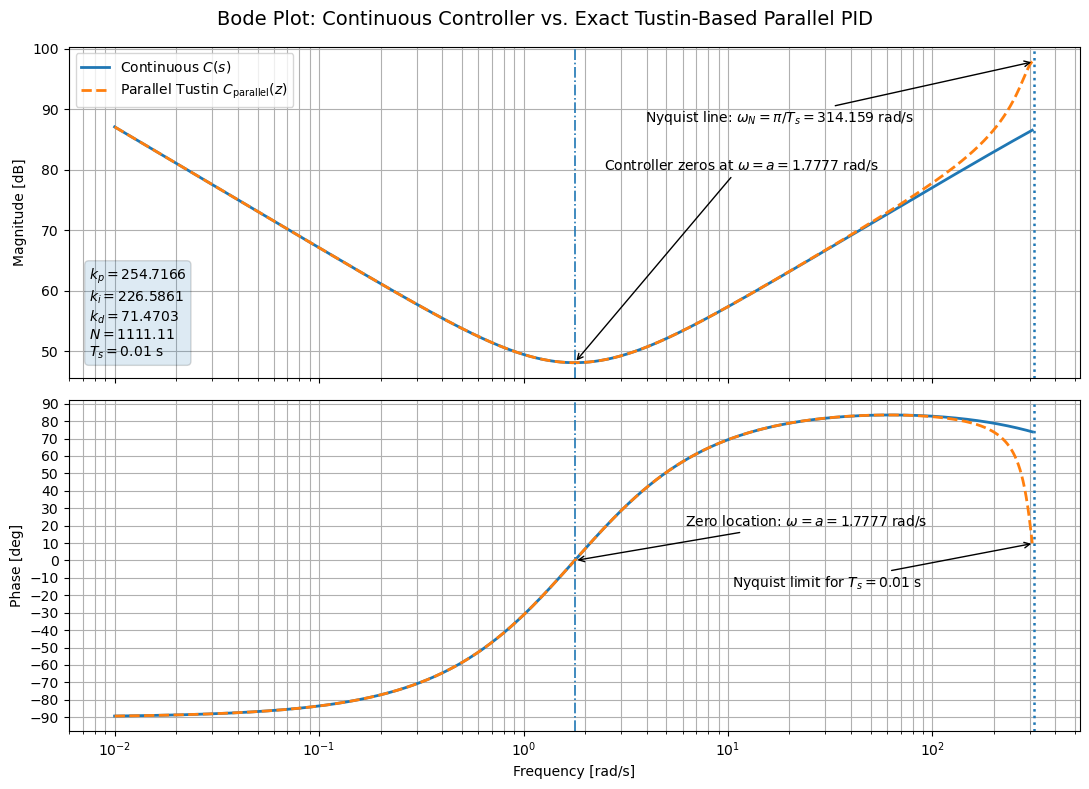

In [185]:
# ============================================================
# Controller/design parameters
# ============================================================
K = 71.699528
a = 1.7777
tau = 0.0009
Ts = 0.01

# ============================================================
# Continuous-time controller
# C(s) = K (s+a)^2 / [ s (tau*s + 1) ]
# ============================================================
s = ct.tf('s')
C_s = K * (s + a)**2 / (s * (tau*s + 1))

# ============================================================
# Continuous-time parallel filtered PID parameters
# C(s) = kp + ki/s + kd * (N s)/(s+N), N = 1/tau
# ============================================================
N = 1 / tau
ki = K * a**2
kp = 2 * K * a - ki * tau
kd = K - kp * tau

# Continuous branches
C_P_s = ct.tf([kp], [1])
C_I_s = ct.tf([ki], [1, 0])          # ki/s
C_D_s = kd * ct.tf([N, 0], [1, N])   # kd * (N s)/(s + N)

# ============================================================
# Exact Tustin-based parallel discretization
# Discretize each branch with Tustin and sum
# ============================================================
C_P_z = ct.c2d(C_P_s, Ts, method='tustin')
C_I_z = ct.c2d(C_I_s, Ts, method='tustin')
C_D_z = ct.c2d(C_D_s, Ts, method='tustin')

C_parallel_z = ct.minreal(C_P_z + C_I_z + C_D_z, verbose=False)

print("\n================ CONTINUOUS CONTROLLER =================\n")
display(C_s)

print("\n================ PARALLEL TUSTIN-DISCRETIZED CONTROLLER =================\n")
display(C_parallel_z)

# ============================================================
# Frequency range
# Only plot up to slightly below Nyquist for the discrete system
# ============================================================
w_nyq = np.pi / Ts
omega = np.logspace(-2, np.log10(0.98 * w_nyq), 3000)

# ============================================================
# Frequency-response helper
# ============================================================
def bode_data(sys, omega):
    mag, phase, omega = ct.frequency_response(sys, omega)
    mag = np.squeeze(mag)
    phase = np.squeeze(phase)

    mag_db = 20 * np.log10(mag)
    phase_deg = np.degrees(np.unwrap(phase))
    return omega, mag_db, phase_deg

omega_c, mag_c_db, phase_c_deg = bode_data(C_s, omega)
omega_d, mag_d_db, phase_d_deg = bode_data(C_parallel_z, omega)

# ============================================================
# Annotation helper
# ============================================================
def interp_logx(x, xp, fp):
    return np.interp(np.log10(x), np.log10(xp), fp)

# Frequencies of interest
w_zero = a
w_pseudo = 1 / tau

# Continuous values for annotations
mag_zero = interp_logx(w_zero, omega_c, mag_c_db)
phase_zero = interp_logx(w_zero, omega_c, phase_c_deg)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

fig.suptitle(
    'Bode Plot: Continuous Controller vs. Exact Tustin-Based Parallel PID',
    fontsize=14
)

# ---------------- Magnitude ----------------
ax[0].semilogx(omega_c, mag_c_db, linewidth=2, label=r'Continuous $C(s)$')
ax[0].semilogx(omega_d, mag_d_db, linewidth=2, linestyle='--',
               label=r'Parallel Tustin $C_{\mathrm{parallel}}(z)$')

ax[0].set_ylabel('Magnitude [dB]')
ax[0].grid(True, which='both')
ax[0].legend()

# Nyquist line
ax[0].axvline(w_nyq, linestyle=':', linewidth=1.8)
ax[0].annotate(
    rf'Nyquist line: $\omega_N=\pi/T_s={w_nyq:.3f}$ rad/s',
    xy=(w_nyq, interp_logx(0.98*w_nyq, omega_d, mag_d_db)),
    xytext=(w_nyq/80, interp_logx(0.98*w_nyq, omega_d, mag_d_db)-10),
    arrowprops=dict(arrowstyle='->')
)

# Controller zero location
ax[0].axvline(w_zero, linestyle='-.', linewidth=1.2)
ax[0].annotate(
    rf'Controller zeros at $\omega=a={w_zero:.4f}$ rad/s',
    xy=(w_zero, mag_zero),
    xytext=(w_zero*1.4, mag_zero+32),
    arrowprops=dict(arrowstyle='->')
)

# Pseudo-pole if it lies in the plotted frequency range
if w_pseudo < omega[-1]:
    mag_pseudo = interp_logx(w_pseudo, omega_c, mag_c_db)
    ax[0].axvline(w_pseudo, linestyle='-.', linewidth=1.2)
    ax[0].annotate(
        rf'Pseudo-pole at $\omega=1/\tau={w_pseudo:.1f}$ rad/s',
        xy=(w_pseudo, mag_pseudo),
        xytext=(w_pseudo/5, mag_pseudo-18),
        arrowprops=dict(arrowstyle='->')
    )

# ---------------- Phase ----------------
ax[1].semilogx(omega_c, phase_c_deg, linewidth=2, label=r'Continuous $C(s)$')
ax[1].semilogx(omega_d, phase_d_deg, linewidth=2, linestyle='--',
               label=r'Parallel Tustin $C_{\mathrm{parallel}}(z)$')

ax[1].set_xlabel('Frequency [rad/s]')
ax[1].set_ylabel('Phase [deg]')
ax[1].grid(True, which='both')

# More phase tick labels
phase_min = min(np.min(phase_c_deg), np.min(phase_d_deg))
phase_max = max(np.max(phase_c_deg), np.max(phase_d_deg))
yt_lo = 10 * np.floor(phase_min / 10)
yt_hi = 10 * np.ceil(phase_max / 10)
ax[1].set_yticks(np.arange(yt_lo, yt_hi + 10, 10))

# Nyquist line
ax[1].axvline(w_nyq, linestyle=':', linewidth=1.8)
ax[1].annotate(
    rf'Nyquist limit for $T_s={Ts}$ s',
    xy=(w_nyq, interp_logx(0.98*w_nyq, omega_d, phase_d_deg)),
    xytext=(w_nyq/30, interp_logx(0.98*w_nyq, omega_d, phase_d_deg)-25),
    arrowprops=dict(arrowstyle='->')
)

# Zero frequency
ax[1].axvline(w_zero, linestyle='-.', linewidth=1.2)
ax[1].annotate(
    rf'Zero location: $\omega=a={w_zero:.4f}$ rad/s',
    xy=(w_zero, phase_zero),
    xytext=(w_zero*3.45, phase_zero+20),
    arrowprops=dict(arrowstyle='->')
)

# Pseudo-pole if visible
if w_pseudo < omega[-1]:
    phase_pseudo = interp_logx(w_pseudo, omega_c, phase_c_deg)
    ax[1].axvline(w_pseudo, linestyle='-.', linewidth=1.2)
    ax[1].annotate(
        rf'Pseudo-pole: $\omega=1/\tau={w_pseudo:.1f}$ rad/s',
        xy=(w_pseudo, phase_pseudo),
        xytext=(w_pseudo/2, phase_pseudo-35),
        arrowprops=dict(arrowstyle='->')
    )

# Add a small text box with PID parameters
textstr = '\n'.join((
    rf'$k_p={kp:.4f}$',
    rf'$k_i={ki:.4f}$',
    rf'$k_d={kd:.4f}$',
    rf'$N={N:.2f}$',
    rf'$T_s={Ts}$ s'
))
ax[0].text(
    0.02, 0.05, textstr,
    transform=ax[0].transAxes,
    fontsize=10,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round', alpha=0.15)
)

plt.tight_layout()
plt.show()

## Experiment 3.4.2

The way to fix the problem is to shoot for a smaller bandwidth and have larger $\tau$ value for the time constant
of the pseudo-differentiator in the PID structure. We suggest you try BW=1 rad/sec and $\tau$ as half
the sample time (T/2). The other thing we recommend is adding a low-pass filter to filter the error
signal. This filter is to attenuate the high-frequency noise in the system. It should have unit gain
and fast dynamics (pole location higher than BW but low enough to get rid of unwanted noise).
Say, f=10/(s+10). You also need to design a controller for a new plant that is augmented by this
filter (the plant is P*f when you design the controller), and put this filter before the controller on
the Controller Arduino (the controller is f*C when you implement it). Don’t forget to discretize
your filter and controller before implementing them, and also make sure you compensate for the
Phase Lag introduced by the Zero Order Hold in the plant.

### Define Symbols and Design Constants

In [186]:
from IPython.display import Math

s, z = sp.symbols('s z')
K, a = sp.symbols('K a', positive=True, real=True)

# Given design parameters
BW = sp.Float('1.0')          # target closed-loop bandwidth [rad/s]
PM = sp.Float('60.0')         # desired phase margin [deg]
Ts = sp.Float('0.01')         # sample time [s]
tau = sp.Float('0.005')       # pseudo-differentiator time constant
plant_num = sp.Float('0.08681')
p1 = sp.Float('0.02397')

display(Eq(sp.Symbol(r'\omega_{BW}'), BW))
display(Eq(sp.Symbol(r'PM'), PM))
display(Eq(sp.Symbol(r'T_s'), Ts))
display(Eq(sp.Symbol(r'\tau'), tau))

Eq(\omega_{BW}, 1.0)

Eq(PM, 60.0)

Eq(T_s, 0.01)

Eq(\tau, 0.005)

### Define Plant $P(s)$, Augmented Plant $P_a(s)$ and Low - Pass Filter $f(s)$ Transfer Functions

In [187]:
# P(s) = 0.08681 / [s(s+0.02397)]
# f(s) = 10/(s+10)
# Pa(s) = P(s)f(s)

P = plant_num / (s * (s + p1))
f_lp = sp.Float('10.0') / (s + sp.Float('10.0'))
Pa = sp.simplify(P * f_lp)

display(Eq(sp.Symbol('P(s)'), P))
display(Eq(sp.Symbol('f(s)'), f_lp))
display(Math(r'P_{a}(s) = P(s) \times f(s)'))
display(Eq(sp.Symbol('P_{a}(s)'), Pa))

Eq(P(s), 0.08681/(s*(s + 0.02397)))

Eq(f(s), 10.0/(s + 10.0))

<IPython.core.display.Math object>

Eq(P_{a}(s), 0.8681/(s*(s + 0.02397)*(s + 10.0)))

### Define Continuous Domain Controller Transfer Function $C(s)$

In [188]:
# C(s) = K (s+a)^2 / [ s (tau s + 1) ]

C = sp.simplify(K * (s + a)**2 / (s * (tau*s + 1)))
display(Eq(sp.Symbol('C(s)'), C))

Eq(C(s), K*(a + s)**2/(s*(0.005*s + 1)))

### Choose New Crossover Frequency from Bandwidth Rule

In [189]:
# omega_bw ~ 1.5 * omega_gc

wgc = sp.N(BW / sp.Float('1.5'))
display(Eq(sp.Symbol(r'\omega_{gc}'), wgc))

Eq(\omega_{gc}, 0.666666666666667)

### Compute ZOH Phase Lag and Frequency Compensation Target

In [190]:
# phi_ZOH ~ (omega_gc * Ts / 2) radians

phi_zoh_rad = -wgc * Ts / 2
phi_zoh_deg = sp.N(phi_zoh_rad * 180 / sp.pi)

phase_target = sp.N(-180 + PM - phi_zoh_deg)  # compensate negative lag by adding margin allowance

display(Eq(sp.Symbol(r'\phi_{ZOH}\,[rad]'), phi_zoh_rad))
display(Eq(sp.Symbol(r'\phi_{ZOH}\,[deg]'), phi_zoh_deg))
display(Eq(sp.Symbol(r'\angle L(j\omega_{gc})\ target\ [deg]'), phase_target))

Eq(\phi_{ZOH}\,[rad], -0.00333333333333333)

Eq(\phi_{ZOH}\,[deg], -0.190985931710274)

Eq(\angle L(j\omega_{gc})\ target\ [deg], -119.80901406829)

### Compute Open - Loop Transfer Function $L(s)$

In [191]:
# L(s) = C(s) * Pa(s)

L = sp.simplify(C * Pa)
display(Math(r'L(s) = C(s) \times P_{a}(s)'))
display(Eq(sp.Symbol('L(s)'), L))

<IPython.core.display.Math object>

Eq(L(s), 0.8681*K*(a + s)**2/(s**2*(0.005*s + 1)*(s + 0.02397)*(s + 10.0)))

### Apply Phase Condition to Solve for $a$

In [192]:
# angle L(jw) =
#   2 atan(w/a)
#   -180
#   -atan(w/0.02397)
#   -atan(w/10)
#   -atan(w*tau)

phase_expr_deg = sp.N(
    2 * sp.atan(wgc / a) * 180 / sp.pi
    - 180
    - sp.atan(wgc / p1) * 180 / sp.pi
    - sp.atan(wgc / sp.Float('10.0')) * 180 / sp.pi
    - sp.atan(wgc * tau) * 180 / sp.pi
)
display(Eq(sp.Symbol(r'\angle L(j\omega_{gc})\ [deg]'), phase_expr_deg))
display(Eq(sp.Symbol(r'Phase\ Target\ [deg]'), phase_target))

Eq(\angle L(j\omega_{gc})\ [deg], 114.591559026165*atan(0.666666666666667/a) - 271.945877344969)

Eq(Phase\ Target\ [deg], -119.80901406829)

#### Solve for New $a$ Method 1

In [193]:
a_sol = sp.nsolve(phase_expr_deg - phase_target, 0.15)
a_sol = sp.N(a_sol)
display(Eq(a, a_sol))

Eq(a, 0.165373183950128)

#### Solve for New $a$ Method 2 (Specify Solver)

In [194]:
a_sol_2 = sp.nsolve(phase_expr_deg - phase_target, a, 0.15,
                  prec=10,   # higher precision if needed
                  solver='newton')
display(Eq(a, a_sol_2))

Eq(a, 0.165373184)

### Apply Magnitude Condition to Solve for New $K$

In [195]:
# |L(jw)| =
# 0.8681*K*(w^2+a^2) /
# [ w^2 * sqrt(w^2+0.02397^2) * sqrt(w^2+10^2) * sqrt(1+(w*tau)^2) ]

mag_expr = sp.simplify(
    sp.Float('0.8681') * K * (wgc**2 + a**2)
    / (
        wgc**2
        * sp.sqrt(wgc**2 + p1**2)
        * sp.sqrt(wgc**2 + sp.Float('10.0')**2)
        * sp.sqrt(1 + (wgc*tau)**2)
    )
)

display(Eq(sp.Symbol(r'|L(j\omega_{gc})|'), mag_expr))
display(Eq(sp.Symbol(r'|L(j\omega_{gc})|\ Target'), 1))

Eq(|L(j\omega_{gc})|, 0.292144437547723*K*(a**2 + 0.444444444444444))

Eq(|L(j\omega_{gc})|\ Target, 1)

In [196]:
K_sol = sp.solve(sp.Eq(mag_expr.subs(a, a_sol), 1), K)[0]
K_sol = sp.N(K_sol)
display(Eq(K, K_sol))

Eq(K, 7.25522908301905)

### Compute Continuous Domian Parallel PID Filtered Form $k_i$, $k_p$, and $k_d$ using Previously Found Equations

In [197]:
# C(s) = kp + ki/s + kd*(N*s)/(s+N), with N = 1/tau

Nf = sp.N(1 / tau)
ki = sp.N(K_sol * a_sol**2)
kp = sp.N(2 * K_sol * a_sol - ki * tau)
kd = sp.N(K_sol - kp * tau)

display(Eq(sp.Symbol('N'), Nf))
display(Eq(sp.Symbol('k_i'), ki))
display(Eq(sp.Symbol('k_p'), kp))
display(Eq(sp.Symbol('k_d'), kd))

Eq(N, 200.0)

Eq(k_i, 0.198418108759752)

Eq(k_p, 2.39864857694906)

Eq(k_d, 7.2432358401343)

### Continuous Domain PID Controller Branch Transfer Functions

In [198]:
C_P_s = sp.simplify(kp)
C_I_s = sp.simplify(ki / s)
C_D_s = sp.simplify(kd * ((Nf * s) / (s + Nf)))

display(Eq(sp.Symbol('C_P(s)'), C_P_s))
display(Eq(sp.Symbol('C_I(s)'), C_I_s))
display(Eq(sp.Symbol('C_D(s)'), C_D_s))

Eq(C_P(s), 2.39864857694906)

Eq(C_I(s), 0.198418108759752/s)

Eq(C_D(s), 1448.64716802686*s/(s + 200.0))

In [199]:
C_parallel_s = sp.simplify(C_P_s + C_I_s + C_D_s)
display(Eq(sp.Symbol('C_{parallel}(s)'), C_parallel_s))

Eq(C_{parallel}(s), (1451.04581660381*s**2 + 479.928133498571*s + 39.6836217519504)/(s*(1.0*s + 200.0)))

### Verify Equality Between $C(s)$ and PID Branched Form

In [200]:
# Optional continuous verification
C_cont_err = sp.simplify(sp.together(C_parallel_s - C.subs({K: K_sol, a: a_sol})))
display(Eq(sp.Symbol('C_{parallel}(s)-C(s)'), C_cont_err))

Eq(C_{parallel}(s)-C(s), (-8.88178419700125e-16*s**2 - 2.27373675443232e-13*s - 5.6843418860808e-14)/(0.005*s**2 + 2.0*s + 200.0))

Note: Above is practically zero, which means that the two are equal.  Discrepancy due to roundoff error.

### Discretize with Tustin (Bilinear) Transform

In [201]:
# s -> (2/Ts) * (z-1)/(z+1)

s_tustin = sp.simplify((sp.Integer(2) / Ts) * (z - 1) / (z + 1))
display(Eq(sp.Symbol(r's_{Tustin}'), s_tustin))

Eq(s_{Tustin}, 200.0*(z - 1)/(z + 1))

### Discretize PID Controller Branches with Tustin (Bilinear) Transform

In [202]:
C_P_z = sp.simplify(C_P_s)  # proportional unchanged
C_I_z = sp.simplify(sp.together(C_I_s.subs(s, s_tustin)))
C_D_z = sp.simplify(sp.together(C_D_s.subs(s, s_tustin)))

display(Eq(sp.Symbol('C_P(z)'), C_P_z))
display(Eq(sp.Symbol('C_I(z)'), C_I_z))
display(Eq(sp.Symbol('C_D(z)'), C_D_z))

Eq(C_P(z), 2.39864857694906)

Eq(C_I(z), 0.00099209054379876*(z + 1)/(z - 1))

Eq(C_D(z), 724.32358401343 - 724.32358401343/z)

### Show Numerator and Denominator of Each Branch

In [203]:
def show_num_den(label, expr):
    num, den = sp.fraction(sp.together(expr))
    num = sp.expand(num)
    den = sp.expand(den)
    display(Eq(sp.Symbol(f'Numerator_{{{label}}}(z)'), num))
    display(Eq(sp.Symbol(f'Denominator_{{{label}}}(z)'), den))
    return num, den

num_I, den_I = show_num_den('I', C_I_z)
num_D, den_D = show_num_den('D', C_D_z)

Eq(Numerator_{I}(z), 0.00099209054379876*z + 0.00099209054379876)

Eq(Denominator_{I}(z), z - 1)

Eq(Numerator_{D}(z), 724.32358401343*z - 724.32358401343)

Eq(Denominator_{D}(z), z)

### Convert each Discrete Branch into $z^{-1}$ Form

In [204]:
def to_zinv(expr):
    num, den = sp.fraction(sp.together(expr))
    num = sp.expand(num)
    den = sp.expand(den)
    deg_num = sp.Poly(num, z).degree()
    deg_den = sp.Poly(den, z).degree()
    deg = max(deg_num, deg_den)
    num_zi = sp.expand(num / z**deg)
    den_zi = sp.expand(den / z**deg)
    return (num_zi / den_zi), num_zi, den_zi

C_I_zinv, C_I_num_zi, C_I_den_zi = to_zinv(C_I_z)
C_D_zinv, C_D_num_zi, C_D_den_zi = to_zinv(C_D_z)

display(Eq(sp.Symbol('C_I(z)\ in\ z^{-1}\ form'), C_I_zinv))
display(Eq(sp.Symbol('C_D(z)\ in\ z^{-1}\ form'), C_D_zinv))

Eq(C_I(z)\ in\ z^{-1}\ form, (0.00099209054379876 + 0.00099209054379876/z)/(1 - 1/z))

Eq(C_D(z)\ in\ z^{-1}\ form, 724.32358401343 - 724.32358401343/z)

### Discretized Low - Pass Filter Transfer Function $f(z)$

In [205]:
f_z = sp.simplify(sp.together(f_lp.subs(s, s_tustin)))
display(Eq(sp.Symbol('f(z)'), f_z))

Eq(f(z), 10.0*(z + 1)/(210.0*z - 190.0))

### Discretized Controller Transfer Function $C(z)$

In [206]:
C_full_z = sp.simplify(sp.together(C.subs({s: s_tustin, K: K_sol, a: a_sol})))
display(Eq(sp.Symbol('C_{full}(z)'), C_full_z))

Eq(C_{full}(z), 0.0181380727075476*(200.16537318395*z - 199.83462681605)**2/(z*(z - 1)))

In [207]:
#C_z = sp.simplify(sp.together(C.subs({s: s_tustin, K: K_sol, a: a_sol})))
#display(Eq(sp.Symbol('C(z)'), C_z))

### Assemble Full Discrete Controller from Branches

In [208]:
C_parallel_z = sp.simplify(sp.together(C_P_z + C_I_z + C_D_z))
display(Eq(sp.Symbol('C_{parallel}(z)'), C_parallel_z))

Eq(C_{parallel}(z), 1.0*(726.723224680923*z**2 - 1451.04482451327*z + 724.32358401343)/(z*(z - 1)))

### Verify Equality between Full Controller Transfer Function and Parallel PID Branch Controller Transfer Functions

In [209]:
C_disc_err = sp.simplify(sp.together(C_parallel_z - C_full_z))
display(Eq(sp.Symbol('C_{parallel}(z)-C_{full}(z)'), C_disc_err))

Eq(C_{parallel}(z)-C_{full}(z), -1.13686837721616e-13/(z*(z - 1)))

Note: Above is practically zero, which means that the two are equal.  Discrepancy due to roundoff error.

### Convert Full Discrete Controller into $z^{-1}$ Form

In [210]:
C_parallel_zinv, C_par_num_zi, C_par_den_zi = to_zinv(C_parallel_z)
display(Eq(sp.Symbol('C_{parallel}(z)\ in z^{-1}\ form'), C_parallel_zinv))

Eq(C_{parallel}(z)\ in z^{-1}\ form, (726.723224680923 - 1451.04482451327/z + 724.32358401343/z**2)/(1 - 1/z))

### Implemented Digital Controller Transfer Function $f(z)C(z)$

In [211]:
FC_z = sp.simplify(sp.together(f_z * C_parallel_z))
FC_zinv, FC_num_zi, FC_den_zi = to_zinv(FC_z)

display(Eq(sp.Symbol('f(z)C(z)'), FC_z))
display(Eq(sp.Symbol('f(z)C(z)\ in\ z^{-1}\ form'), FC_zinv))

Eq(f(z)C(z), 10.0*(z + 1)*(726.723224680923*z**2 - 1451.04482451327*z + 724.32358401343)/(z*(z - 1)*(210.0*z - 190.0)))

Eq(f(z)C(z)\ in\ z^{-1}\ form, (7267.23224680923 - 7243.21599832343/z - 7267.21240499835/z**2 + 7243.2358401343/z**3)/(210.0 - 400.0/z + 190.0/z**2))

### Convert $f(z)$ and $C(z)$ into $z^{-1}$ form 

In [212]:
def to_zinv(expr):
    num, den = sp.fraction(sp.together(expr))
    num = sp.expand(num)
    den = sp.expand(den)

    deg_num = sp.Poly(num, z).degree()
    deg_den = sp.Poly(den, z).degree()
    deg = max(deg_num, deg_den)

    num_zi = sp.expand(num / z**deg)
    den_zi = sp.expand(den / z**deg)
    return sp.simplify(num_zi / den_zi), num_zi, den_zi

f_zinv, f_num_zi, f_den_zi = to_zinv(f_z)
C_zinv, C_num_zi, C_den_zi = to_zinv(C_full_z)

display(Eq(sp.Symbol('f(z)\; in\; z^{-1}\; form'), f_zinv))
display(Eq(sp.Symbol('C(z)\; in\; z^{-1}\; form'), C_zinv))

Eq(f(z)\; in\; z^{-1}\; form, 10.0*(z + 1)/(210.0*z - 190.0))

Eq(C(z)\; in\; z^{-1}\; form, (726.723224680923*z**2 - 1451.04482451327*z + 724.32358401343)/(z*(z - 1)))

### Display Overall Implemented Digital Controller Transfer Function $f(z)C(z)$

In [213]:
FC_z = sp.simplify(sp.together(f_z * C_full_z))
FC_zinv, FC_num_zi, FC_den_zi = to_zinv(FC_z)

display(Eq(sp.Symbol('f(z)C(z)'), FC_z))
display(Eq(sp.Symbol('f(z)C(z)\; in\; z^{-1}\; form'), FC_zinv))

Eq(f(z)C(z), 0.181380727075476*(z + 1)*(200.16537318395*z - 199.83462681605)**2/(z*(z - 1)*(210.0*z - 190.0)))

Eq(f(z)C(z)\; in\; z^{-1}\; form, (7267.23224680923*z**3 - 7243.21599832343*z**2 - 7267.21240499835*z + 7243.2358401343)/(z*(210.0*z**2 - 400.0*z + 190.0)))

### Summary of Results

In [214]:
# ============================================================
# STEP 13: Plain-text summary
# ============================================================
print("\n================ DESIGN SUMMARY ================\n")
print(f"omega_gc               = {float(wgc):.6f} rad/s")
print(f"phi_zoh_deg            = {float(phi_zoh_deg):.6f} deg")
print(f"phase target           = {float(phase_target):.6f} deg")
print(f"a                      = {float(a_sol):.8f}")
print(f"K                      = {float(K_sol):.8f}")
print(f"kp                     = {float(kp):.8f}")
print(f"ki                     = {float(ki):.8f}")
print(f"kd                     = {float(kd):.8f}")
print(f"N                      = {float(Nf):.8f}")

print("\nDiscrete low-pass filter f(z):")
display(f_z)

print("\nDiscrete controller C(z):")
display(C_z)

print("\nDiscrete controller C(z) in z^-1 form:")
display(C_zinv)

print("\nImplemented digital controller f(z)C(z) in z^-1 form:")
display(FC_zinv)

print("\nDiscrete branches in z^-1 form:")
print("C_I(z) =")
display(C_I_zinv)
print("\nC_D(z) =")
display(C_D_zinv)


================ DESIGN SUMMARY ================

omega_gc               = 0.666667 rad/s
phi_zoh_deg            = -0.190986 deg
phase target           = -119.809014 deg
a                      = 0.16537318
K                      = 7.25522908
kp                     = 2.39864858
ki                     = 0.19841811
kd                     = 7.24323584
N                      = 200.00000000

Discrete low-pass filter f(z):


10.0*(z + 1)/(210.0*z - 190.0)


Discrete controller C(z):


TransferFunction(
array([ 12369.45680703, -24303.00452468,  11937.38815982]),
array([ 1.        , -0.30508475, -0.69491525]),
dt=0.01,
name='sys[84]$sampled', outputs=1, inputs=1)


Discrete controller C(z) in z^-1 form:


...

(7267.23224680923*z**3 - 7243.21599832343*z**2 - 7267.21240499835*z + 7243.2358401343)/(z*(210.0*z**2 - 400.0*z + 190.0))


Discrete branches in z^-1 form:
C_I(z) =


(0.00099209054379876 + 0.00099209054379876/z)/(1 - 1/z)


C_D(z) =


724.32358401343 - 724.32358401343/z

## Verify with Control Systems Library

### Import Libraries

In [215]:
from scipy.optimize import fsolve

### Display Plant $P(s)$, Low - Pass Filter $f(s)$ and Augmented Plant $P_a(s)$ Transfer Functions 

In [216]:
BW = 1.0
PM = 60.0
Ts = 0.01
tau = 0.005

# Original plant and added filter
s = ct.tf('s')
P = 0.08681 / (s * (s + 0.02397))
f_lp = 10 / (s + 10)
Pa = ct.minreal(P * f_lp, verbose=False)

print("\n================ PLANTS ================\n")
print("P(s) =")
display(P)
print("\nf(s) =")
display(f_lp)
print("\nAugmented plant Pa(s) = P(s)f(s) =")
display(Pa)


================ PLANTS ================

P(s) =


TransferFunction(
array([0.08681]),
array([1.     , 0.02397, 0.     ]),
outputs=1, inputs=1)


f(s) =


TransferFunction(
array([10]),
array([ 1, 10]),
outputs=1, inputs=1)


Augmented plant Pa(s) = P(s)f(s) =


TransferFunction(
array([0.8681]),
array([ 1.     , 10.02397,  0.2397 ,  0.     ]),
outputs=1, inputs=1)

### Choose Gain Crossover Frequency $\omega_{gc}$ from Bandwidth Rule and Calculate Phase Target

In [217]:
wgc = BW / 1.5
phi_zoh_deg = -(wgc * Ts / 2.0) * 180 / np.pi
phase_target = -180 + PM - phi_zoh_deg

print("\n================ DESIGN TARGETS ================\n")
print(f"Target BW                = {BW:.6f} rad/s")
print(f"Chosen wgc               = {wgc:.6f} rad/s")
print(f"ZOH phase lag            = {phi_zoh_deg:.6f} deg")
print(f"Compensated phase target = {phase_target:.6f} deg")


================ DESIGN TARGETS ================

Target BW                = 1.000000 rad/s
Chosen wgc               = 0.666667 rad/s
ZOH phase lag            = -0.190986 deg
Compensated phase target = -119.809014 deg


### Solve Phase Condition for New $a$

In [218]:
def phase_equation(a):
    phase_deg = (
        2 * np.degrees(np.arctan(wgc / a))
        - 180
        - np.degrees(np.arctan(wgc / 0.02397))
        - np.degrees(np.arctan(wgc / 10.0))
        - np.degrees(np.arctan(wgc * tau))
    )
    return phase_deg - phase_target

a_sol = fsolve(phase_equation, x0=0.15)[0]

print("\n================ SOLVE FOR New a ================\n")
print(f"a = {a_sol:.10f}")


================ SOLVE FOR New a ================

a = 0.1653731840


### Solve Magnitude Condition for New $K$

In [219]:
mag_factor = (
    0.8681 * (wgc**2 + a_sol**2)
    / (
        wgc**2
        * np.sqrt(wgc**2 + 0.02397**2)
        * np.sqrt(wgc**2 + 10.0**2)
        * np.sqrt(1 + (wgc*tau)**2)
    )
)

K_sol = 1.0 / mag_factor

print("\n================ SOLVE FOR K ================\n")
print(f"K = {K_sol:.10f}")


================ SOLVE FOR K ================

K = 7.2552290830


### Compute Redesigned Continuous Domain Controller $C(s)$

In [220]:
C = K_sol * (s + a_sol)**2 / (s * (tau*s + 1))

print("\n================ REDESIGNED CONTINUOUS CONTROLLER ================\n")
display(C)


================ REDESIGNED CONTINUOUS CONTROLLER ================



TransferFunction(
array([7.25522908, 2.39964067, 0.19841811]),
array([0.005, 1.   , 0.   ]),
outputs=1, inputs=1)

### Compute Continuous Domain PID $k_i$, $k_p$, and $k_d$ Gains using Previously Found Equations

In [221]:
Nf = 1 / tau
ki = K_sol * a_sol**2
kp = 2 * K_sol * a_sol - ki * tau
kd = K_sol - kp * tau

print("\n================ CONTINUOUS PID PARAMETERS ================\n")
print(f"kp = {kp:.10f}")
print(f"ki = {ki:.10f}")
print(f"kd = {kd:.10f}")
print(f"N  = {Nf:.10f}")


================ CONTINUOUS PID PARAMETERS ================

kp = 2.3986485769
ki = 0.1984181088
kd = 7.2432358401
N  = 200.0000000000


### Continuous Branch Transfer Functions

In [222]:
C_P_s = ct.tf([kp], [1])
C_I_s = ct.tf([ki], [1, 0])           # ki / s
C_D_s = kd * ct.tf([N, 0], [1, N])    # kd * (N s)/(s + N)

C_parallel_s = ct.minreal(C_P_s + C_I_s + C_D_s, verbose=False)

In [223]:
print("\n================ CONTINUOUS BRANCHES ================\n")
print("Proportional branch C_P(s) =")
display(C_P_s)

print("\nIntegral branch C_I(s) =")
display(C_I_s)

print("\nDerivative branch C_D(s) =")
display(C_D_s)

print("\nSum of continuous branches C_parallel(s) =")
display(C_parallel_s)


================ CONTINUOUS BRANCHES ================

Proportional branch C_P(s) =


TransferFunction(
array([2.39864858]),
array([1]),
dt=None,
outputs=1, inputs=1)


Integral branch C_I(s) =


TransferFunction(
array([0.19841811]),
array([1, 0]),
outputs=1, inputs=1)


Derivative branch C_D(s) =


TransferFunction(
array([8048.03982237,    0.        ]),
array([1.00000000e+00, 1.11111111e+03]),
outputs=1, inputs=1)


Sum of continuous branches C_parallel(s) =


TransferFunction(
array([8050.43847095, 2665.36350361,  220.46456529]),
array([1.00000000e+00, 1.11111111e+03, 0.00000000e+00]),
outputs=1, inputs=1)

### Print Numerator and Denominator Coefficients

In [224]:
def print_tf_coeffs(name, sys):
    num = np.squeeze(sys.num[0][0])
    den = np.squeeze(sys.den[0][0])
    print(f"\n{name}")
    display(sys)
    print("Numerator coefficients:", num)
    print("Denominator coefficients:", den)

print("\n================ COEFFICIENTS ================\n")
print_tf_coeffs("C_P(s)", C_P_s)
print_tf_coeffs("C_I(s)", C_I_s)
print_tf_coeffs("C_D(s)", C_D_s)


================ COEFFICIENTS ================


C_P(s)


TransferFunction(
array([2.39864858]),
array([1]),
dt=None,
outputs=1, inputs=1)

Numerator coefficients: 2.3986485769490504
Denominator coefficients: 1

C_I(s)


TransferFunction(
array([0.19841811]),
array([1, 0]),
outputs=1, inputs=1)

Numerator coefficients: 0.1984181087597516
Denominator coefficients: [1 0]

C_D(s)


TransferFunction(
array([8048.03982237,    0.        ]),
array([1.00000000e+00, 1.11111111e+03]),
outputs=1, inputs=1)

Numerator coefficients: [8048.03982237    0.        ]
Denominator coefficients: [1.00000000e+00 1.11111111e+03]


### Verify Equality

In [225]:
C_cont_err = ct.minreal(C_parallel_s - C, verbose=False)

print("\nContinuous verification C_parallel(s) - C(s) =")
display(C_cont_err)


Continuous verification C_parallel(s) - C(s) =


TransferFunction(
array([6599.39265434,    0.        ,    0.        ]),
array([1.00000000e+00, 1.31111111e+03, 2.22222222e+05]),
outputs=1, inputs=1)

### Discretize Each Parallel PID Controller Branch using Tustin (Bilinear Transform)

In [226]:
C_P_z = ct.c2d(C_P_s, Ts, method='tustin')
C_I_z = ct.c2d(C_I_s, Ts, method='tustin')
C_D_z = ct.c2d(C_D_s, Ts, method='tustin')

C_parallel_z = ct.minreal(C_P_z + C_I_z + C_D_z, verbose=False)

print("\n================ DISCRETE BRANCHES (TUSTIN) ================\n")
print("Proportional branch C_P(z) =")
display(C_P_z)

print("\nIntegral branch C_I(z) =")
display(C_I_z)

print("\nDerivative branch C_D(z) =")
display(C_D_z)

print("\nSum of discrete branches C_parallel(z) =")
display(C_parallel_z)


================ DISCRETE BRANCHES (TUSTIN) ================

Proportional branch C_P(z) =


TransferFunction(
array([ 2.39864858, -2.39864858]),
array([ 1., -1.]),
dt=0.01,
name='sys[172]$sampled', outputs=1, inputs=1)


Integral branch C_I(z) =


TransferFunction(
array([0.00099209, 0.00099209]),
array([ 1., -1.]),
dt=0.01,
name='sys[173]$sampled', outputs=1, inputs=1)


Derivative branch C_D(z) =


TransferFunction(
array([ 1227.66709155, -1227.66709155]),
array([1.        , 0.69491525]),
dt=0.01,
name='sys[176]$sampled', outputs=1, inputs=1)


Sum of discrete branches C_parallel(z) =


TransferFunction(
array([ 1230.06673222, -2456.06429283,  1226.00092364]),
array([ 1.        , -0.30508476, -0.69491527]),
dt=0.01,
outputs=1, inputs=1)

### Print Numerator and Denominator Coefficients

In [227]:
def print_tf_coeffs(name, sys):
    num = np.squeeze(sys.num[0][0])
    den = np.squeeze(sys.den[0][0])
    print(f"\n{name}")
    display(sys)
    print("Numerator coefficients:", num)
    print("Denominator coefficients:", den)

print("\n================ COEFFICIENTS ================\n")
print_tf_coeffs("C_P(z)", C_P_z)
print_tf_coeffs("C_I(z)", C_I_z)
print_tf_coeffs("C_D(z)", C_D_z)


================ COEFFICIENTS ================


C_P(z)


TransferFunction(
array([ 2.39864858, -2.39864858]),
array([ 1., -1.]),
dt=0.01,
name='sys[172]$sampled', outputs=1, inputs=1)

Numerator coefficients: [ 2.39864858 -2.39864858]
Denominator coefficients: [ 1. -1.]

C_I(z)


TransferFunction(
array([0.00099209, 0.00099209]),
array([ 1., -1.]),
dt=0.01,
name='sys[173]$sampled', outputs=1, inputs=1)

Numerator coefficients: [0.00099209 0.00099209]
Denominator coefficients: [ 1. -1.]

C_D(z)


TransferFunction(
array([ 1227.66709155, -1227.66709155]),
array([1.        , 0.69491525]),
dt=0.01,
name='sys[176]$sampled', outputs=1, inputs=1)

Numerator coefficients: [ 1227.66709155 -1227.66709155]
Denominator coefficients: [1.         0.69491525]


### Discretize Low - Pass Filter and Controller using Tustin (Bilinear) Transform

In [228]:
f_z = ct.c2d(f_lp, Ts, method='tustin')
C_z = ct.c2d(C, Ts, method='tustin')

print("\n================ DISCRETE FILTER AND CONTROLLER ================\n")
print("f(z) =")
display(f_z)
print("\nC(z) =")
display(C_z)


================ DISCRETE FILTER AND CONTROLLER ================

f(z) =


TransferFunction(
array([0.04761905, 0.04761905]),
array([ 1.       , -0.9047619]),
dt=0.01,
name='sys[156]$sampled', outputs=1, inputs=1)


C(z) =


TransferFunction(
array([  726.72322468, -1451.04482451,   724.32358401]),
array([ 1., -1.,  0.]),
dt=0.01,
name='sys[171]$sampled', outputs=1, inputs=1)

### Display Discretized Filter $\times$ Controller Transfer Function $F(z)C(z)$

In [229]:
FC_z = ct.minreal(f_z * C_z, verbose=False)

print("\nImplemented digital controller f(z)C(z) =")
display(FC_z)


Implemented digital controller f(z)C(z) =


TransferFunction(
array([ 34.60586784, -34.49150475, -34.60577336,  34.49159924]),
array([ 1.       , -1.9047619,  0.9047619,  0.       ]),
dt=0.01,
outputs=1, inputs=1)

### Verify Continuous Design

In [230]:
# Loop designed on augmented continuous plant

L = ct.minreal(C * Pa, verbose=False)
Tcl = ct.minreal(ct.feedback(L, 1), verbose=False)

gm, pm, wg, wp = ct.margin(L)
bw_cl = ct.bandwidth(Tcl)

Ljwgc = ct.evalfr(L, 1j * wgc)
mag_at_wgc = abs(Ljwgc)
phase_at_wgc = np.degrees(np.angle(Ljwgc))
if phase_at_wgc > 0:
    phase_at_wgc -= 360

print("\n================ CONTINUOUS DESIGN VERIFICATION ================\n")
print(f"|L(jwgc)|                = {mag_at_wgc:.10f}")
print(f"20log10|L(jwgc)|         = {20*np.log10(mag_at_wgc):.10f} dB")
print(f"angle L(jwgc)            = {phase_at_wgc:.10f} deg")
print(f"PM from margin()         = {pm:.10f} deg")
print(f"PM crossover wp          = {wp:.10f} rad/s")
print(f"Closed-loop bandwidth    = {bw_cl:.10f} rad/s")


================ CONTINUOUS DESIGN VERIFICATION ================

|L(jwgc)|                = 1.0000000000
20log10|L(jwgc)|         = -0.0000000000 dB
angle L(jwgc)            = -119.8090140683 deg
PM from margin()         = 60.1909859317 deg
PM crossover wp          = 0.6666666667 rad/s
Closed-loop bandwidth    = 0.9567801601 rad/s


### Show Discretized Filter and Discretized Controller Coefficients

In [231]:
print("\n================ DISCRETE COEFFICIENTS ================\n")
print("f(z) numerator   =", np.squeeze(f_z.num[0][0]))
print("f(z) denominator =", np.squeeze(f_z.den[0][0]))
print("C(z) numerator   =", np.squeeze(C_z.num[0][0]))
print("C(z) denominator =", np.squeeze(C_z.den[0][0]))
print("f(z)C(z) numerator   =", np.squeeze(FC_z.num[0][0]))
print("f(z)C(z) denominator =", np.squeeze(FC_z.den[0][0]))


================ DISCRETE COEFFICIENTS ================

f(z) numerator   = [0.04761905 0.04761905]
f(z) denominator = [ 1.        -0.9047619]
C(z) numerator   = [  726.72322468 -1451.04482451   724.32358401]
C(z) denominator = [ 1. -1.  0.]
f(z)C(z) numerator   = [ 34.60586784 -34.49150475 -34.60577336  34.49159924]
f(z)C(z) denominator = [ 1.        -1.9047619  0.9047619  0.       ]


## Bode Plots and Step Response

In [232]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ============================================================
# 1) DESIGN SETTINGS
# ============================================================
BW_target = 1.0          # rad/s
PM_target = 60.0         # deg
Ts = 0.01                # s
tau = Ts / 2             # 0.005
w_nyq = np.pi / Ts       # Nyquist rad/s

# Frequency grid for continuous/discrete comparisons
omega = np.logspace(-3, np.log10(0.98 * w_nyq), 4000)

# ============================================================
# 2) ORIGINAL PLANT AND NEW FILTER
# ============================================================
s = ct.tf('s')

P = 0.08681 / (s * (s + 0.02397))
f_lp = 10 / (s + 10)

# Augmented design plant
P_aug = ct.minreal(P * f_lp, verbose=False)

# ============================================================
# 3) REDESIGN CONTROLLER FOR BW = 1 rad/s, tau = 0.005
#
# Use the same rule of thumb as before:
#   BW ~ 1.5 * w_gc
# and compensate ZOH phase lag approximately by +w_gc*Ts/2
# ============================================================
w_gc = BW_target / 1.5

phi_zoh_deg = -(w_gc * Ts / 2.0) * 180.0 / np.pi
phase_target = -180.0 + PM_target - phi_zoh_deg

def phase_equation(a):
    phase_deg = (
        2 * np.degrees(np.arctan(w_gc / a))
        - 180.0
        - np.degrees(np.arctan(w_gc / 0.02397))
        - np.degrees(np.arctan(w_gc / 10.0))
        - np.degrees(np.arctan(w_gc * tau))
    )
    return phase_deg - phase_target

a_new = float(fsolve(phase_equation, x0=0.15)[0])

mag_factor = (
    0.8681 * (w_gc**2 + a_new**2)
    / (
        w_gc**2
        * np.sqrt(w_gc**2 + 0.02397**2)
        * np.sqrt(w_gc**2 + 10.0**2)
        * np.sqrt(1.0 + (w_gc * tau)**2)
    )
)

K_new = 1.0 / mag_factor

C = K_new * (s + a_new)**2 / (s * (tau * s + 1))

# Continuous PID-equivalent parameters
N = 1.0 / tau
ki = K_new * a_new**2
kp = 2.0 * K_new * a_new - ki * tau
kd = K_new - kp * tau

# ============================================================
# 4) DISCRETIZE CONTROLLER, FILTER, AND PLANT WITH TUSTIN
# ============================================================
Cz = ct.c2d(C, Ts, method='tustin')
fz = ct.c2d(f_lp, Ts, method='tustin')
Pz = ct.c2d(P, Ts, method='tustin')

# Discrete augmented plant for comparison
P_aug_z = ct.minreal(Pz * fz, verbose=False)

# ============================================================
# 5) CLOSED-LOOP CONTINUOUS MODEL
# Design is based on augmented plant P*f
# ============================================================
L = ct.minreal(C * P_aug, verbose=False)
T = ct.minreal(ct.feedback(L, 1), verbose=False)

gm, pm, wg, wp = ct.margin(L)
bw_closed = ct.bandwidth(T)

Ljwgc = ct.evalfr(L, 1j * w_gc)
mag_at_wgc = abs(Ljwgc)
phase_at_wgc = np.degrees(np.angle(Ljwgc))
if phase_at_wgc > 0:
    phase_at_wgc -= 360

In [233]:
# ============================================================
# 6) HELPER FUNCTIONS
# ============================================================
def bode_data(sys, omega):
    mag, phase, omega = ct.frequency_response(sys, omega)
    mag = np.squeeze(mag)
    phase = np.squeeze(phase)
    mag_db = 20.0 * np.log10(mag)
    phase_deg = np.degrees(np.unwrap(phase))
    return omega, mag_db, phase_deg

def interp_logx(x, xp, fp):
    return np.interp(np.log10(x), np.log10(xp), fp)

def bode_compare_plot(sys_c, sys_d, title, label_c, label_d,
                      annotate_breaks=None, show_nyquist=True,
                      show_pm=False, pm_value=None, pm_freq=None,
                      show_bw=False, bw_value=None):
    wc, magc_db, phasec_deg = bode_data(sys_c, omega)
    wd, magd_db, phased_deg = bode_data(sys_d, omega)

    fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    fig.suptitle(title, fontsize=14)

    # Magnitude
    ax[0].semilogx(wc, magc_db, linewidth=2, label=label_c)
    ax[0].semilogx(wd, magd_db, '--', linewidth=2, label=label_d)
    ax[0].set_ylabel('Magnitude [dB]')
    ax[0].grid(True, which='both')
    ax[0].legend()

    # Phase
    ax[1].semilogx(wc, phasec_deg, linewidth=2, label=label_c)
    ax[1].semilogx(wd, phased_deg, '--', linewidth=2, label=label_d)
    ax[1].set_xlabel('Frequency [rad/s]')
    ax[1].set_ylabel('Phase [deg]')
    ax[1].grid(True, which='both')

    # Denser phase ticks
    phase_min = min(np.min(phasec_deg), np.min(phased_deg))
    phase_max = max(np.max(phasec_deg), np.max(phased_deg))
    yt_lo = 10 * np.floor(phase_min / 10)
    yt_hi = 10 * np.ceil(phase_max / 10)
    ax[1].set_yticks(np.arange(yt_lo, yt_hi + 10, 10))

    if show_nyquist:
        for axes in ax:
            axes.axvline(w_nyq, linestyle=':', linewidth=1.6)
        ax[0].annotate(
            rf'Nyquist line: $\omega_N=\pi/T_s={w_nyq:.2f}$ rad/s',
            xy=(w_nyq, interp_logx(0.98 * w_nyq, wd, magd_db)),
            xytext=(w_nyq / 1000, interp_logx(0.98 * w_nyq, wd, magd_db) - 0),
            arrowprops=dict(arrowstyle='->')
        )

    if annotate_breaks:
        for wb, text in annotate_breaks:
            for axes in ax:
                axes.axvline(wb, linestyle='-.', linewidth=1.1)
            ax[0].annotate(
                text,
                xy=(wb, interp_logx(wb, wc, magc_db)),
                xytext=(wb / 100, interp_logx(wb, wc, magc_db) - 0),
                arrowprops=dict(arrowstyle='->')
            )

    if show_pm and pm_value is not None and pm_freq is not None and np.isfinite(pm_freq) and pm_freq > 0:
        for axes in ax:
            axes.axvline(pm_freq, linestyle='--', linewidth=1.2)
        ax[0].axhline(0, linestyle='--', linewidth=1.0)
        ax[1].axhline(-180, linestyle='--', linewidth=1.0)
        phase_at_pm = interp_logx(pm_freq, wc, phasec_deg)
        ax[1].annotate(
            rf'PM $\approx {pm_value:.2f}^\circ$ at $\omega={pm_freq:.3f}$ rad/s',
            xy=(pm_freq, phase_at_pm),
            xytext=(pm_freq * 1.6, phase_at_pm + 20),
            arrowprops=dict(arrowstyle='->')
        )

    if show_bw and bw_value is not None and np.isfinite(bw_value) and bw_value > 0:
        for axes in ax:
            axes.axvline(bw_value, linestyle='--', linewidth=1.2)
        ax[0].annotate(
            rf'Bandwidth $\approx {bw_value:.3f}$ rad/s',
            xy=(bw_value, interp_logx(bw_value, wc, magc_db)),
            xytext=(bw_value * 1.5, interp_logx(bw_value, wc, magc_db) - 10),
            arrowprops=dict(arrowstyle='->')
        )

    plt.tight_layout()
    plt.show()

In [234]:
# ============================================================
# 7) PRINT DESIGN SUMMARY
# ============================================================
print("\n================ NEW CONTROLLER DESIGN ================\n")
print(f"BW target                    = {BW_target:.6f} rad/s")
print(f"Chosen w_gc                  = {w_gc:.6f} rad/s")
print(f"ZOH phase lag compensation   = {-phi_zoh_deg:.6f} deg")
print(f"Phase target used            = {phase_target:.6f} deg")
print(f"a                            = {a_new:.10f}")
print(f"K                            = {K_new:.10f}")
print(f"kp                           = {kp:.10f}")
print(f"ki                           = {ki:.10f}")
print(f"kd                           = {kd:.10f}")
print(f"N                            = {N:.10f}")

print("\n================ LOOP / CLOSED-LOOP VERIFICATION ================\n")
print(f"|L(jw_gc)|                   = {mag_at_wgc:.10f}")
print(f"20log10|L(jw_gc)|            = {20*np.log10(mag_at_wgc):.10f} dB")
print(f"angle L(jw_gc)               = {phase_at_wgc:.10f} deg")
print(f"Phase margin                 = {pm:.10f} deg")
print(f"PM crossover wp              = {wp:.10f} rad/s")
print(f"Closed-loop bandwidth        = {bw_closed:.10f} rad/s")


================ NEW CONTROLLER DESIGN ================

BW target                    = 1.000000 rad/s
Chosen w_gc                  = 0.666667 rad/s
ZOH phase lag compensation   = 0.190986 deg
Phase target used            = -119.809014 deg
a                            = 0.1653731840
K                            = 7.2552290830
kp                           = 2.3986485769
ki                           = 0.1984181088
kd                           = 7.2432358401
N                            = 200.0000000000

================ LOOP / CLOSED-LOOP VERIFICATION ================

|L(jw_gc)|                   = 1.0000000000
20log10|L(jw_gc)|            = -0.0000000000 dB
angle L(jw_gc)               = -119.8090140683 deg
Phase margin                 = 60.1909859317 deg
PM crossover wp              = 0.6666666667 rad/s
Closed-loop bandwidth        = 0.9567801601 rad/s


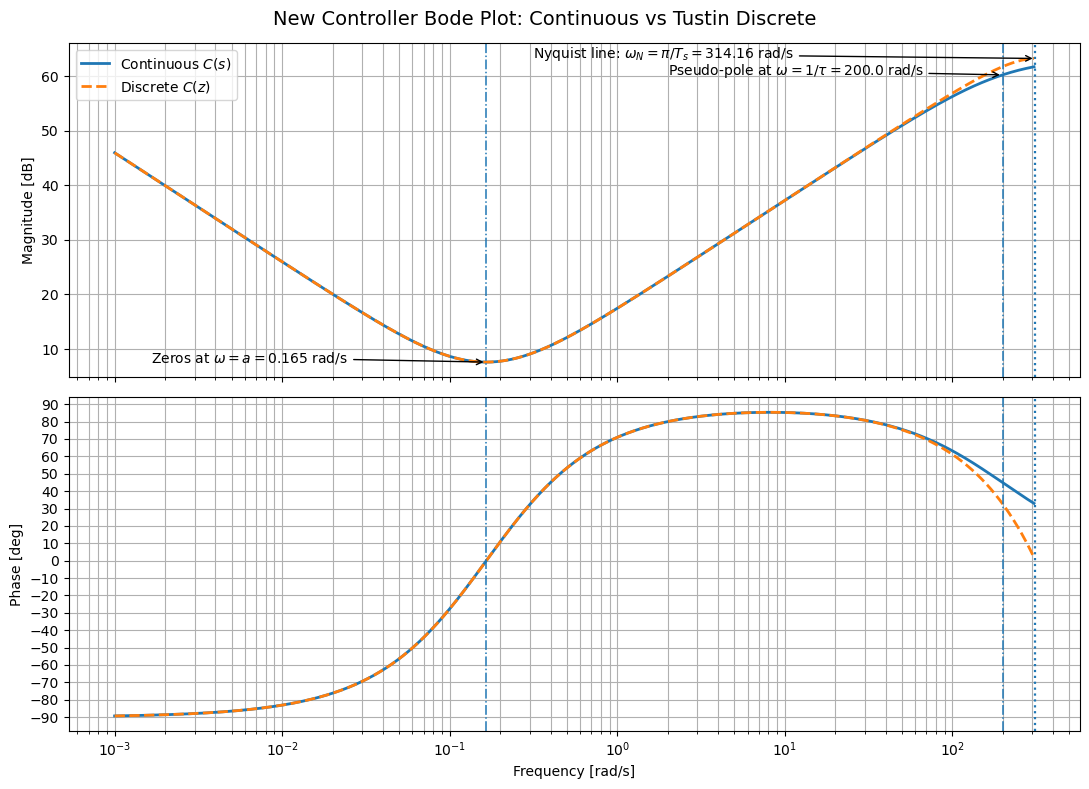

In [235]:
# ============================================================
# 8) PLOT: CONTROLLER BODE, CONTINUOUS VS DISCRETE
# ============================================================
controller_breaks = [
    (a_new, rf'Zeros at $\omega=a={a_new:.3f}$ rad/s'),
    (1.0 / tau, rf'Pseudo-pole at $\omega=1/\tau={1.0/tau:.1f}$ rad/s')
]

bode_compare_plot(
    C, Cz,
    title='New Controller Bode Plot: Continuous vs Tustin Discrete',
    label_c=r'Continuous $C(s)$',
    label_d=r'Discrete $C(z)$',
    annotate_breaks=controller_breaks,
    show_nyquist=True
)

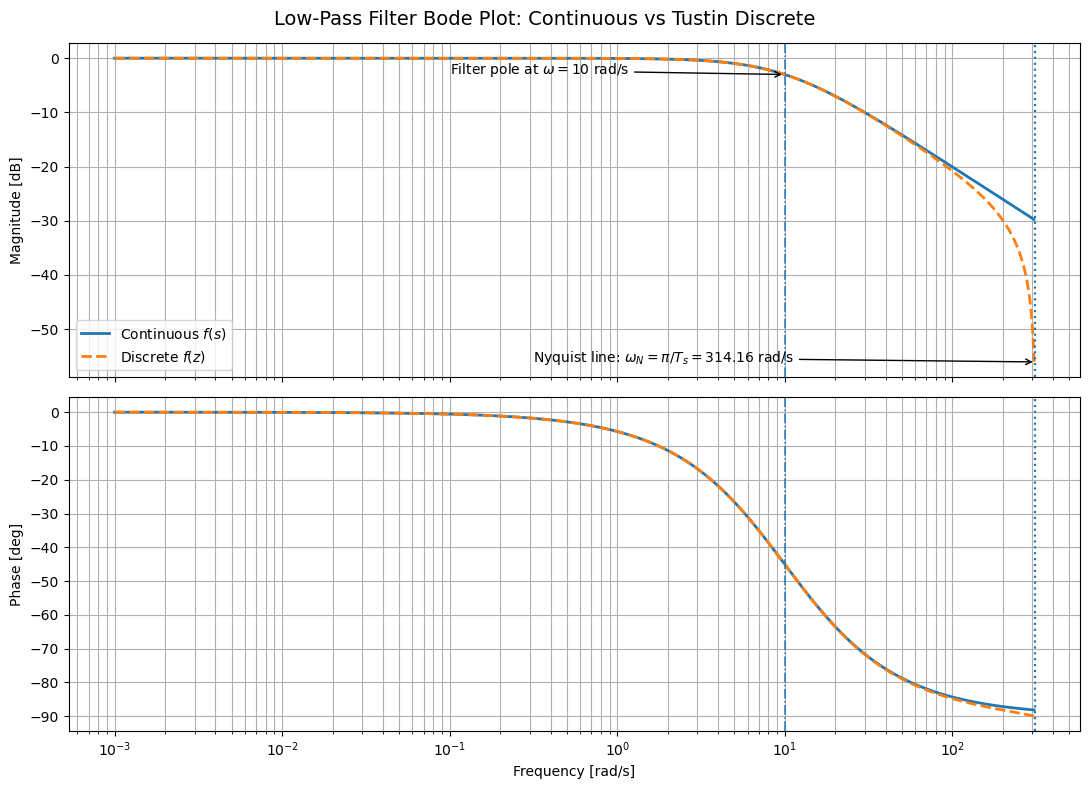

In [236]:
# ============================================================
# 9) PLOT: FILTER BODE, CONTINUOUS VS DISCRETE
# ============================================================
filter_breaks = [
    (10.0, r'Filter pole at $\omega=10$ rad/s')
]

bode_compare_plot(
    f_lp, fz,
    title='Low-Pass Filter Bode Plot: Continuous vs Tustin Discrete',
    label_c=r'Continuous $f(s)$',
    label_d=r'Discrete $f(z)$',
    annotate_breaks=filter_breaks,
    show_nyquist=True
)

In [237]:
# ============================================================
# 6) HELPER FUNCTIONS
# ============================================================
def bode_data(sys, omega):
    mag, phase, omega = ct.frequency_response(sys, omega)
    mag = np.squeeze(mag)
    phase = np.squeeze(phase)
    mag_db = 20.0 * np.log10(mag)
    phase_deg = np.degrees(np.unwrap(phase))
    return omega, mag_db, phase_deg

def interp_logx(x, xp, fp):
    return np.interp(np.log10(x), np.log10(xp), fp)

def bode_compare_plot(sys_c, sys_d, title, label_c, label_d,
                      annotate_breaks=None, show_nyquist=True,
                      show_pm=False, pm_value=None, pm_freq=None,
                      show_bw=False, bw_value=None):
    wc, magc_db, phasec_deg = bode_data(sys_c, omega)
    wd, magd_db, phased_deg = bode_data(sys_d, omega)

    fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    fig.suptitle(title, fontsize=14)

    # Magnitude
    ax[0].semilogx(wc, magc_db, linewidth=2, label=label_c)
    ax[0].semilogx(wd, magd_db, '--', linewidth=2, label=label_d)
    ax[0].set_ylabel('Magnitude [dB]')
    ax[0].grid(True, which='both')
    ax[0].legend()

    # Phase
    ax[1].semilogx(wc, phasec_deg, linewidth=2, label=label_c)
    ax[1].semilogx(wd, phased_deg, '--', linewidth=2, label=label_d)
    ax[1].set_xlabel('Frequency [rad/s]')
    ax[1].set_ylabel('Phase [deg]')
    ax[1].grid(True, which='both')

    # Denser phase ticks
    phase_min = min(np.min(phasec_deg), np.min(phased_deg))
    phase_max = max(np.max(phasec_deg), np.max(phased_deg))
    yt_lo = 10 * np.floor(phase_min / 10)
    yt_hi = 10 * np.ceil(phase_max / 10)
    ax[1].set_yticks(np.arange(yt_lo, yt_hi + 10, 10))

    if show_nyquist:
        for axes in ax:
            axes.axvline(w_nyq, linestyle=':', linewidth=1.6)
        ax[0].annotate(
            rf'Nyquist line: $\omega_N=\pi/T_s={w_nyq:.2f}$ rad/s',
            xy=(w_nyq, interp_logx(0.98 * w_nyq, wd, magd_db)),
            xytext=(w_nyq / 1000, interp_logx(0.98 * w_nyq, wd, magd_db) - 0),
            arrowprops=dict(arrowstyle='->')
        )

    if annotate_breaks:
        for wb, text in annotate_breaks:
            for axes in ax:
                axes.axvline(wb, linestyle='-.', linewidth=1.1)
            ax[0].annotate(
                text,
                xy=(wb, interp_logx(wb, wc, magc_db)),
                xytext=(wb * 1, interp_logx(wb, wc, magc_db) + 20),
                arrowprops=dict(arrowstyle='->')
            )

    if show_pm and pm_value is not None and pm_freq is not None and np.isfinite(pm_freq) and pm_freq > 0:
        for axes in ax:
            axes.axvline(pm_freq, linestyle='--', linewidth=1.2)
        ax[0].axhline(0, linestyle='--', linewidth=1.0)
        ax[1].axhline(-180, linestyle='--', linewidth=1.0)
        phase_at_pm = interp_logx(pm_freq, wc, phasec_deg)
        ax[1].annotate(
            rf'PM $\approx {pm_value:.2f}^\circ$ at $\omega={pm_freq:.3f}$ rad/s',
            xy=(pm_freq, phase_at_pm),
            xytext=(pm_freq * 1.6, phase_at_pm + 20),
            arrowprops=dict(arrowstyle='->')
        )

    if show_bw and bw_value is not None and np.isfinite(bw_value) and bw_value > 0:
        for axes in ax:
            axes.axvline(bw_value, linestyle='--', linewidth=1.2)
        ax[0].annotate(
            rf'Bandwidth $\approx {bw_value:.3f}$ rad/s',
            xy=(bw_value, interp_logx(bw_value, wc, magc_db)),
            xytext=(bw_value * 1.5, interp_logx(bw_value, wc, magc_db) - 10),
            arrowprops=dict(arrowstyle='->')
        )

    plt.tight_layout()
    plt.show()

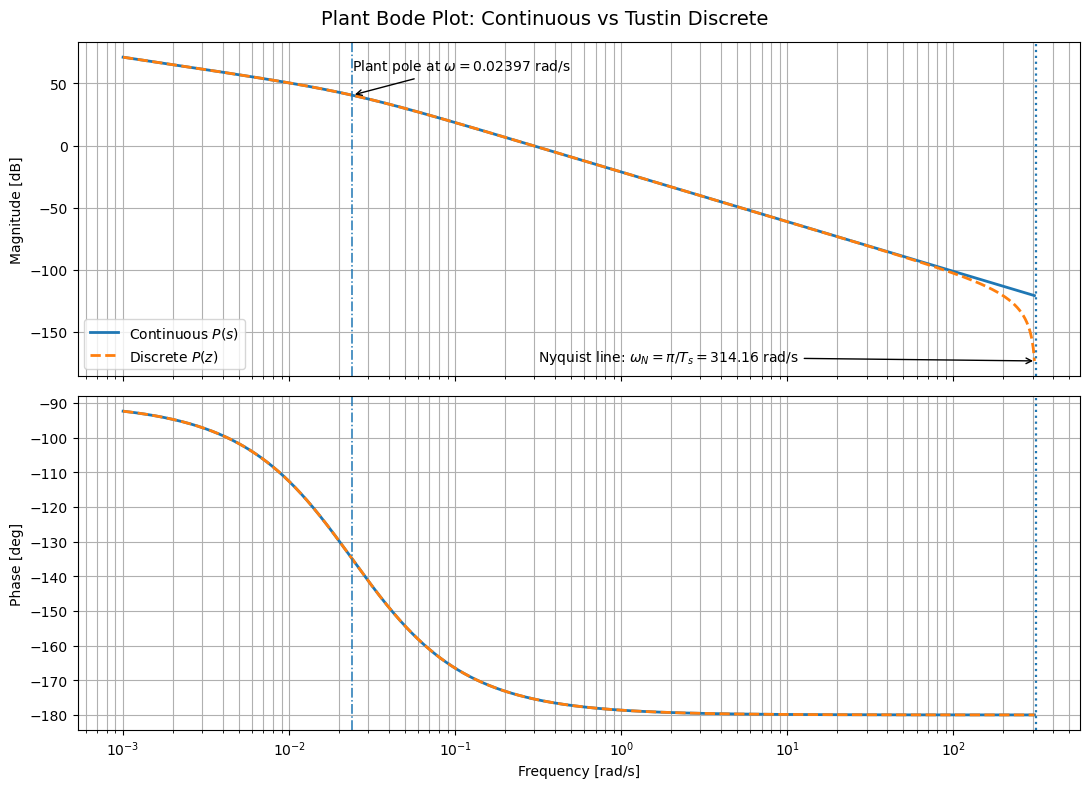

In [238]:
# ============================================================
# 10) PLOT: PLANT BODE, CONTINUOUS VS DISCRETE
# ============================================================
plant_breaks = [
    (0.02397, r'Plant pole at $\omega=0.02397$ rad/s')
]

bode_compare_plot(
    P, Pz,
    title='Plant Bode Plot: Continuous vs Tustin Discrete',
    label_c=r'Continuous $P(s)$',
    label_d=r'Discrete $P(z)$',
    annotate_breaks=plant_breaks,
    show_nyquist=True
)

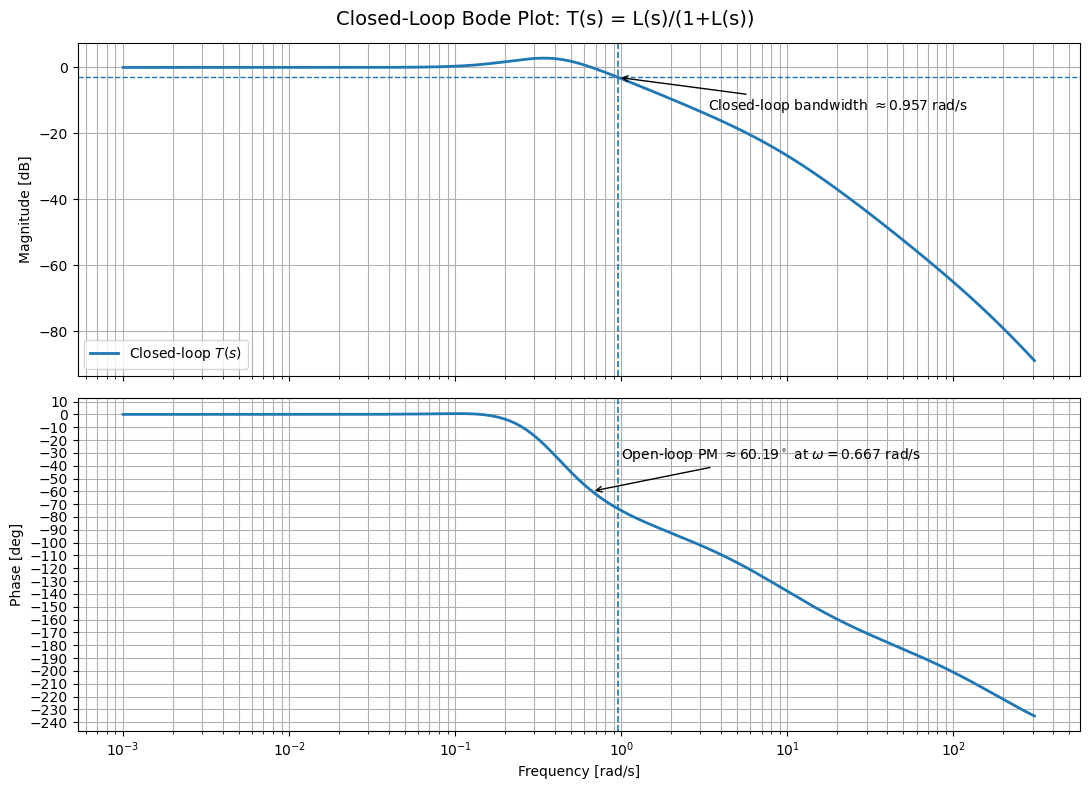

In [239]:
# ============================================================
# 11) CLOSED-LOOP BODE PLOT
# Continuous closed-loop transfer function
# ============================================================
omega_T, magT_db, phaseT_deg = bode_data(T, omega)

fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Closed-Loop Bode Plot: T(s) = L(s)/(1+L(s))', fontsize=14)

ax[0].semilogx(omega_T, magT_db, linewidth=2, label=r'Closed-loop $T(s)$')
ax[0].axhline(-3, linestyle='--', linewidth=1.0)
ax[0].set_ylabel('Magnitude [dB]')
ax[0].grid(True, which='both')
ax[0].legend()

ax[1].semilogx(omega_T, phaseT_deg, linewidth=2, label=r'Closed-loop $T(s)$')
ax[1].set_xlabel('Frequency [rad/s]')
ax[1].set_ylabel('Phase [deg]')
ax[1].grid(True, which='both')

# Denser phase ticks
yt_lo = 10 * np.floor(np.min(phaseT_deg) / 10)
yt_hi = 10 * np.ceil(np.max(phaseT_deg) / 10)
ax[1].set_yticks(np.arange(yt_lo, yt_hi + 10, 10))

# Bandwidth annotation
if np.isfinite(bw_closed) and bw_closed > 0:
    for axes in ax:
        axes.axvline(bw_closed, linestyle='--', linewidth=1.2)
    ax[0].annotate(
        rf'Closed-loop bandwidth $\approx {bw_closed:.3f}$ rad/s',
        xy=(bw_closed, interp_logx(bw_closed, omega_T, magT_db)),
        xytext=(bw_closed * 3.5, interp_logx(bw_closed, omega_T, magT_db) - 10),
        arrowprops=dict(arrowstyle='->')
    )

# Phase margin note on closed-loop figure for reference
if np.isfinite(wp) and wp > 0:
    ax[1].annotate(
        rf'Open-loop PM $\approx {pm:.2f}^\circ$ at $\omega={wp:.3f}$ rad/s',
        xy=(wp, interp_logx(wp, omega_T, phaseT_deg)),
        xytext=(wp * 1.5, interp_logx(wp, omega_T, phaseT_deg) + 25),
        arrowprops=dict(arrowstyle='->')
    )

plt.tight_layout()
plt.show()

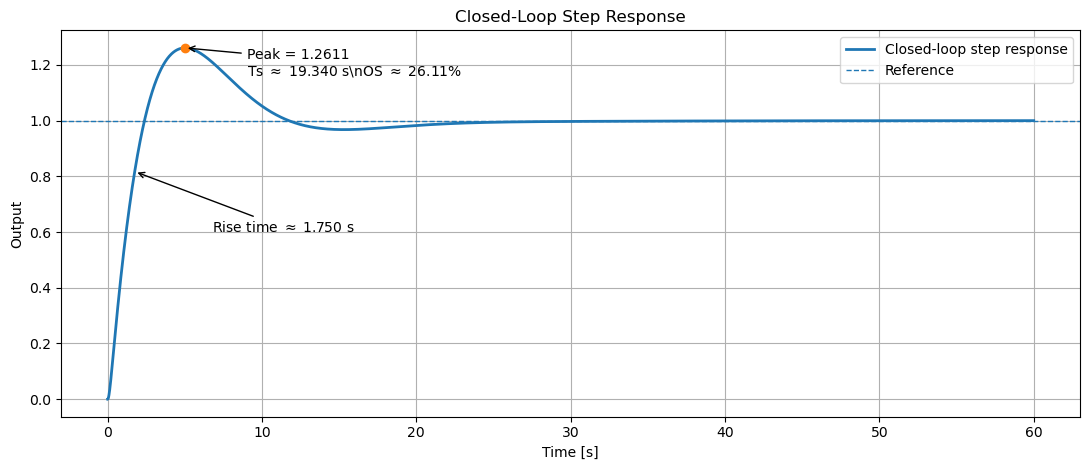

In [240]:
# ============================================================
# 12) CLOSED-LOOP STEP RESPONSE
# ============================================================
t = np.linspace(0, 60, 6000)
t_step, y_step = ct.step_response(T, T=t)
info = ct.step_info(T)

plt.figure(figsize=(11, 4.8))
plt.plot(t_step, y_step, linewidth=2, label='Closed-loop step response')
plt.axhline(1.0, linestyle='--', linewidth=1.0, label='Reference')

peak_idx = np.argmax(y_step)
peak_t = t_step[peak_idx]
peak_y = y_step[peak_idx]

plt.plot(peak_t, peak_y, 'o')
plt.annotate(
    f'Peak = {peak_y:.4f}\n'
    rf'Ts $\approx$ {info["SettlingTime"]:.3f} s\n'
    rf'OS $\approx$ {info["Overshoot"]:.2f}%',
    xy=(peak_t, peak_y),
    xytext=(peak_t + 4, peak_y - 0.1),
    arrowprops=dict(arrowstyle='->')
)

if np.isfinite(info["RiseTime"]):
    plt.annotate(
        rf'Rise time $\approx$ {info["RiseTime"]:.3f} s',
        xy=(info["RiseTime"], np.interp(info["RiseTime"], t_step, y_step)),
        xytext=(info["RiseTime"] + 5, 0.6),
        arrowprops=dict(arrowstyle='->')
    )

plt.title('Closed-Loop Step Response')
plt.xlabel('Time [s]')
plt.ylabel('Output')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Q8) Does your design work well on the Arduinos for Experiment 3.4.1 ? Provide step response plots by gathering input and output data from the Controller Board as you deem necessary.

Answer: Yes, the design works well on the Arduino's and recreates the results from 3.4.1 with the reduced bandwidth controller with additional low-pass filtering.  Step responses are provided in the Report.